# Análisis de competencias - EAL 2020-2024

Análisis para orientar las políticas de formación de RapidExpress hacia las competencias más relevantes para operación, coordinación, atención, resolución de incidencias, adaptación y mandos intermedios.

Fuente principal: CSV preprocesados en `Equip_31/Data/pre_processed_2020_2024/EAL_15062026`.

## Resumen del enfoque

- `EAL-17` y `EAL-18` se usan solo como contexto: formación instalada y necesidades detectadas.
- `EAL-16`, `EAL-20`, `EAL-21` y `EAL-22` son las tablas principales de competencias.
- `Servicios` se usa como benchmark sectorial cuando no existe detalle de Transporte y almacenamiento.
- `Más de 499 trabajadores` se usa como referencia de tamaño comparable con RapidExpress.
- Todas las comparaciones son descriptivas salvo que exista un test válido con errores muestrales correctamente emparejados.

## Contexto y criterios metodológicos

- Periodo: 2020-2024.
- Foco: competencias consideradas importantes y competencias en las que se formó.
- Métrica: porcentajes y diferencias en puntos porcentuales cuando los denominadores son comparables.
- La EAL no sigue necesariamente a las mismas empresas cada año: la serie no es un panel.
- Sin test o intervalo válido se hablará de `tendencia descriptiva`, `posición relativa`, `benchmark` o `se observa`.
- No se analizarán medios formativos (`EAL-18a`), barreras (`EAL-24`) ni motivos de no formación (`EAL-25`).

## 1. Configuración


In [1]:
from pathlib import Path
import re
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from textwrap import wrap


pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)


def encontrar_raiz_repo(inicio=None):
    ruta = Path(inicio or Path.cwd()).resolve()
    for candidata in [ruta, *ruta.parents]:
        if (candidata / "Equip_31/Data").exists() and (candidata / "Equip_31/Scripts").exists():
            return candidata
    raise FileNotFoundError("No se encontró la raíz del repositorio con Equip_31.")


REPO_ROOT = encontrar_raiz_repo()
DATA_PREPROCESSED = REPO_ROOT / "Equip_31/Data/pre_processed_2020_2024/EAL_15062026"

ANIOS = [2020, 2021, 2022, 2023, 2024]

SECTOR_OBJETIVO = "TRANSPORTE Y ALMACENAMIENTO"
SECTOR_COMPARACION = "SERVICIOS"
TAMANO_OBJETIVO = "MÁS DE 499 TRABAJADORES"
CCAA_SEDES = [
    "CATALUÑA",
    "MADRID (COMUNIDAD DE)",
    "COMUNITAT VALENCIANA",
    "ANDALUCÍA",
    "PAÍS VASCO",
]

print("Raíz repo:", REPO_ROOT)
print("Carpeta preprocesada:", DATA_PREPROCESSED.relative_to(REPO_ROOT))
print("Preprocesado existe:", DATA_PREPROCESSED.exists())


Raíz repo: /Users/sabina/Documents/DataAnalytics/IT_Academy/simulador/ProjecteData
Carpeta preprocesada: Equip_31/Data/pre_processed_2020_2024/EAL_15062026
Preprocesado existe: True


In [2]:
plt.rcParams["figure.figsize"] = (13, 7)
plt.rcParams["figure.dpi"] = 160
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["font.family"] = "DejaVu Sans"


def preparar_ax(
    ax,
    xlabel="Año",
    ylabel="Porcentaje (%)",
    grid="y",
    mostrar_xlabel=True,
    mostrar_ylabel=True
):
    ax.figure.patch.set_alpha(0)
    ax.set_facecolor("none")

    ax.set_xlabel(
        xlabel if mostrar_xlabel else "",
        color="black",
        fontsize=12
    )
    ax.set_ylabel(
        ylabel if mostrar_ylabel else "",
        color="black",
        fontsize=12
    )

    ax.tick_params(axis="both", colors="black", labelsize=11)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(PALETA["gris_claro"])
    ax.spines["bottom"].set_color(PALETA["gris_claro"])

    if grid == "y":
        ax.grid(axis="y", color=PALETA["gris_claro"], alpha=0.35, linewidth=0.8)
    elif grid == "x":
        ax.grid(axis="x", color=PALETA["gris_claro"], alpha=0.35, linewidth=0.8)
    elif grid == "both":
        ax.grid(axis="both", color=PALETA["gris_claro"], alpha=0.25, linewidth=0.7)
    else:
        ax.grid(False)

    return ax


def formato_pct(valor):
    return f"{valor:.1f}".replace(".", ",")


def etiquetar_final(ax, x, y, texto, color, dx=0.12):
    ax.text(
        x + dx,
        y,
        texto,
        color=color,
        fontsize=9.8,
        fontweight="bold",
        va="center",
        clip_on=False
    )

def leyenda_comun(fig, handles, labels, y=0.98, ncol=3):
    """
    Leyenda común opcional para gráficos con varios paneles.
    Úsala solo si no vas a hacer la leyenda en Canva.
    """
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, y),
        ncol=ncol,
        frameon=False,
        fontsize=10,
        labelcolor=PALETA["texto"]
    )

## 2. Carga de datos preprocesados

Se reconstruye la base larga desde los CSV preprocesados del alcance aprobado: `EAL-16`, `EAL-16a` (solo 2020), `EAL-17`, `EAL-18`, `EAL-20`, `EAL-21` y `EAL-22`.

La función de año solo acepta carpetas cuyo nombre completo cumple `20\d{2}`. Así evita confundir `pre_processed_2020_2024` con el año real del archivo.

In [3]:
def limpiar_celda(valor):
    if pd.isna(valor):
        return ""
    return re.sub(r"\s+", " ", str(valor).strip())


def normalizar_nombre_columna(valor):
    return limpiar_celda(valor).upper()


def detectar_anio_desde_path(path):
    for parte in Path(path).parts:
        if re.fullmatch(r"20\d{2}", parte):
            return int(parte)
    raise ValueError(f"No se pudo detectar año en la ruta: {path}")


def detectar_ambito_seccion(etiqueta):
    etiqueta_norm = normalizar_nombre_columna(etiqueta)
    mapa = {
        "TAMAÑO DE LA EMPRESA": "tamano_empresa",
        "ACTIVIDAD ECONÓMICA": "sector",
        "COMUNIDAD AUTÓNOMA": "ccaa",
    }
    return mapa.get(etiqueta_norm)


def ambito_desde_titulo(titulo):
    titulo_norm = normalizar_nombre_columna(titulo)
    patrones_tamano = [
        "DE 5 A 49 TRABAJADORES",
        "DE 50 A 249 TRABAJADORES",
        "DE 250 A 499 TRABAJADORES",
        "MÁS DE 499 TRABAJADORES",
    ]
    for patron in patrones_tamano:
        if patron in titulo_norm:
            return "tamano_empresa"
    return "total_empresas"


def extraer_codigo_tabla(titulo, nombre_archivo):
    match = re.search(r"(EAL-\d+[a-z]?)", titulo, flags=re.IGNORECASE)
    if match:
        return match.group(1).upper()
    return Path(nombre_archivo).stem.upper()


def combinar_encabezados(fila_superior, fila_inferior=None):
    superiores = [limpiar_celda(v) for v in fila_superior]
    superiores_ffill = []
    actual = ""
    for valor in superiores:
        if valor:
            actual = valor
        superiores_ffill.append(actual)

    if fila_inferior is None:
        return superiores_ffill

    inferiores = [limpiar_celda(v) for v in fila_inferior]
    encabezados = []
    for superior, inferior in zip(superiores_ffill, inferiores):
        if inferior and superior and inferior.upper() != superior.upper():
            encabezados.append(f"{superior} - {inferior}")
        else:
            encabezados.append(superior or inferior)
    return encabezados


def leer_tabla_preprocesada(path):
    anio = detectar_anio_desde_path(path)
    raw = pd.read_csv(path, header=None, dtype=str, keep_default_na=False)
    raw = raw.map(limpiar_celda)

    titulo_idxs = [
        idx for idx, valor in raw.iloc[:, 0].items()
        if re.match(r"^EAL-\d+[a-z]?\.", valor, flags=re.IGNORECASE)
    ]

    registros = []
    for pos, titulo_idx in enumerate(titulo_idxs):
        siguiente_titulo = titulo_idxs[pos + 1] if pos + 1 < len(titulo_idxs) else len(raw)
        titulo = raw.iat[titulo_idx, 0]
        tabla = extraer_codigo_tabla(titulo, path.name)
        ambito_bloque = ambito_desde_titulo(titulo)

        header_idx = titulo_idx + 2
        if header_idx >= siguiente_titulo:
            continue

        posible_subheader_idx = header_idx + 1
        tiene_subheader = (
            posible_subheader_idx < siguiente_titulo
            and raw.iat[posible_subheader_idx, 0] == ""
            and any(raw.iloc[posible_subheader_idx, 1:].astype(bool))
        )

        if tiene_subheader:
            encabezados = combinar_encabezados(raw.iloc[header_idx].tolist(), raw.iloc[posible_subheader_idx].tolist())
            data_start = posible_subheader_idx + 1
        else:
            encabezados = combinar_encabezados(raw.iloc[header_idx].tolist())
            data_start = header_idx + 1

        ambito_actual = ambito_bloque
        for row_idx in range(data_start, siguiente_titulo):
            categoria = limpiar_celda(raw.iat[row_idx, 0])
            if not categoria:
                # Algunas tablas continúan horizontalmente en un segundo bloque
                # de encabezados dentro de la misma hoja (p. ej. EAL-16a 2020 y EAL-22).
                fila_encabezado = raw.iloc[row_idx].tolist()
                if any(limpiar_celda(valor) for valor in fila_encabezado[1:]):
                    encabezados = combinar_encabezados(fila_encabezado)
                continue

            ambito_seccion = detectar_ambito_seccion(categoria)
            if ambito_seccion:
                ambito_actual = ambito_seccion
                continue

            ambito_fila = "total_empresas" if normalizar_nombre_columna(categoria) == "TOTAL" else ambito_actual

            for col_idx in range(1, raw.shape[1]):
                variable = limpiar_celda(encabezados[col_idx]) if col_idx < len(encabezados) else ""
                valor = limpiar_celda(raw.iat[row_idx, col_idx])
                if not variable or not valor:
                    continue

                porcentaje = pd.to_numeric(valor.replace(",", "."), errors="coerce")
                if pd.isna(porcentaje):
                    continue

                registros.append({
                    "anio": anio,
                    "tabla": tabla,
                    "pregunta": titulo,
                    "ambito": ambito_fila,
                    "categoria": categoria,
                    "variable": normalizar_nombre_columna(variable),
                    "porcentaje": porcentaje,
                    "archivo_origen": str(path.relative_to(REPO_ROOT)),
                })

    return pd.DataFrame(registros)


TABLAS_COMPETENCIAS = ["EAL-16.csv", "EAL-16a.csv", "EAL-20.csv", "EAL-21.csv", "EAL-22.csv"]
TABLAS_CONTEXTO = ["EAL-17.csv", "EAL-18.csv"]
ARCHIVOS_ANALISIS = TABLAS_COMPETENCIAS + TABLAS_CONTEXTO

csvs_preprocesados = sorted(
    DATA_PREPROCESSED / str(anio) / nombre_archivo
    for anio in ANIOS
    for nombre_archivo in ARCHIVOS_ANALISIS
    if (DATA_PREPROCESSED / str(anio) / nombre_archivo).exists()
)

if not DATA_PREPROCESSED.exists():
    raise FileNotFoundError(f"No existe la carpeta preprocesada esperada: {DATA_PREPROCESSED}")
if not csvs_preprocesados:
    raise FileNotFoundError(f"No se encontraron CSV preprocesados en: {DATA_PREPROCESSED}")

df_largo = pd.concat([leer_tabla_preprocesada(path) for path in csvs_preprocesados], ignore_index=True)

inventario = (
    df_largo
    .groupby(["anio", "tabla", "archivo_origen"], dropna=False)
    .size()
    .reset_index(name="n_registros")
    .assign(estado="cargado")
    .sort_values(["anio", "tabla"])
    .reset_index(drop=True)
)

print("CSV preprocesados leídos:", len(csvs_preprocesados))
print("df_largo:", df_largo.shape)
print("inventario:", inventario.shape)
display(inventario.groupby(["anio", "estado"], dropna=False).size().reset_index(name="n_hojas"))


CSV preprocesados leídos: 31
df_largo: (5096, 8)
inventario: (55, 5)


,anio,estado,n_hojas
0,2020,cargado,7
1,2021,cargado,12
2,2022,cargado,12
3,2023,cargado,12
4,2024,cargado,12


## 3. Validación rápida de cobertura


In [4]:
resumen_tablas = (
    df_largo
    .assign(tabla_base=lambda d: d["tabla"].str.extract(r"^(EAL-\d+)", expand=False))
    .groupby(["anio", "tabla_base"], dropna=False)
    .size()
    .reset_index(name="n_registros")
    .pivot(index="tabla_base", columns="anio", values="n_registros")
    .fillna(0)
    .astype(int)
)

display(resumen_tablas)


anio,2020,2021,2022,2023,2024
tabla_base,,,,,
EAL-16,208,350,350,350,350
EAL-17,192,192,192,192,192
EAL-18,192,192,192,192,192
EAL-20,72,66,66,66,66
EAL-21,48,44,44,44,44
EAL-22,216,198,198,198,198


## 4. Etiquetado del alcance

Se distingue entre tablas principales de competencias y tablas de contexto. No se cargan medios, barreras ni motivos de no formación.

In [5]:
def tabla_base(tabla):
    match = re.match(r"^(EAL-\d+)", str(tabla))
    return match.group(1) if match else str(tabla)


def asignar_tematica(tabla):
    mapa = {
        "EAL-16": "competencias_prioritarias",
        "EAL-17": "contexto_empresas_formacion",
        "EAL-18": "contexto_necesidades_formativas",
        "EAL-20": "competencias_formadas_tamano",
        "EAL-21": "competencias_formadas_sector",
        "EAL-22": "competencias_formadas_ccaa",
    }
    return mapa.get(tabla_base(tabla), "fuera_alcance")


def normalizar_texto(valor):
    if pd.isna(valor):
        return ""
    return re.sub(r"\s+", " ", str(valor).strip()).upper()


df_base = df_largo.copy()
df_base["tabla_base"] = df_base["tabla"].map(tabla_base)
df_base["tematica"] = df_base["tabla"].map(asignar_tematica)

for col in ["pregunta", "ambito", "categoria", "variable"]:
    df_base[f"{col}_norm"] = df_base[col].map(normalizar_texto)

resumen_tematicas = (
    df_base.groupby(["tematica", "anio"], dropna=False)
    .size()
    .reset_index(name="n_registros")
)
display(resumen_tematicas.pivot(index="tematica", columns="anio", values="n_registros").fillna(0).astype(int))

anio,2020,2021,2022,2023,2024
tematica,,,,,
competencias_formadas_ccaa,216,198,198,198,198
competencias_formadas_sector,48,44,44,44,44
competencias_formadas_tamano,72,66,66,66,66
competencias_prioritarias,208,350,350,350,350
contexto_empresas_formacion,192,192,192,192,192
contexto_necesidades_formativas,192,192,192,192,192


## 5. Filtros del análisis

Se identifican Transporte y almacenamiento para el contexto, Servicios como benchmark de competencias, empresas de más de 499 trabajadores y CCAA de las sedes.

In [6]:
def contiene(texto, patron):
    return texto.str.contains(patron, case=False, regex=False, na=False)

ccaa_sedes_set = set(CCAA_SEDES)

df_base["es_sector_transporte"] = (
    df_base["categoria_norm"].eq(SECTOR_OBJETIVO)
    | df_base["variable_norm"].eq(SECTOR_OBJETIVO)
    | contiene(df_base["pregunta_norm"], SECTOR_OBJETIVO)
)

df_base["es_sector_servicios"] = (
    df_base["categoria_norm"].eq(SECTOR_COMPARACION)
    | df_base["variable_norm"].eq(SECTOR_COMPARACION)
    | contiene(df_base["pregunta_norm"], SECTOR_COMPARACION)
)

df_base["es_tamano_499"] = (
    df_base["categoria_norm"].eq(TAMANO_OBJETIVO)
    | df_base["variable_norm"].eq(TAMANO_OBJETIVO)
    | contiene(df_base["pregunta_norm"], TAMANO_OBJETIVO)
    | contiene(df_base["pregunta_norm"], "MÁS DE 499")
)

df_base["es_ccaa_sede"] = (
    df_base["categoria_norm"].isin(ccaa_sedes_set)
    | df_base["variable_norm"].isin(ccaa_sedes_set)
)

df_base["es_total"] = (
    df_base["ambito_norm"].eq("TOTAL_EMPRESAS")
    | df_base["categoria_norm"].eq("TOTAL")
    | df_base["variable_norm"].eq("TOTAL")
)

df_base["incluir_analisis"] = (
    df_base["es_sector_transporte"]
    | df_base["es_sector_servicios"]
    | df_base["es_tamano_499"]
    | df_base["es_ccaa_sede"]
    | df_base["es_total"]
)

resumen_filtros = pd.DataFrame({
    "filtro": ["sector_transporte", "sector_servicios", "tamano_499", "ccaa_sede", "total", "incluido_analisis"],
    "n_registros": [
        df_base["es_sector_transporte"].sum(),
        df_base["es_sector_servicios"].sum(),
        df_base["es_tamano_499"].sum(),
        df_base["es_ccaa_sede"].sum(),
        df_base["es_total"].sum(),
        df_base["incluir_analisis"].sum(),
    ]
})

display(resumen_filtros)


,filtro,n_registros
0,sector_transporte,73
1,sector_servicios,256
2,tamano_499,329
3,ccaa_sede,580
4,total,3071
5,incluido_analisis,3616


## 6. Dataframes de trabajo

Los subconjuntos permiten conservar trazabilidad, pero los hallazgos principales se construirán únicamente con las tablas de competencias y los dos contextos aprobados.

In [7]:
columnas_analisis = [
    "anio", "tabla", "tabla_base", "tematica", "pregunta", "ambito", "categoria", "variable", "porcentaje",
    "es_sector_transporte", "es_sector_servicios", "es_tamano_499", "es_ccaa_sede", "es_total",
]

df_analisis = (
    df_base.loc[df_base["incluir_analisis"], columnas_analisis]
    .sort_values(["anio", "tematica", "tabla", "ambito", "categoria", "variable"])
    .reset_index(drop=True)
)

df_sector_transporte = df_analisis[df_analisis["es_sector_transporte"]].reset_index(drop=True)
df_sector_servicios = df_analisis[df_analisis["es_sector_servicios"]].reset_index(drop=True)
df_tamano_499 = df_analisis[df_analisis["es_tamano_499"]].reset_index(drop=True)
df_ccaa_sedes = df_analisis[df_analisis["es_ccaa_sede"]].reset_index(drop=True)

print("df_analisis:", df_analisis.shape)
print("df_sector_transporte:", df_sector_transporte.shape)
print("df_sector_servicios:", df_sector_servicios.shape)
print("df_tamano_499:", df_tamano_499.shape)
print("df_ccaa_sedes:", df_ccaa_sedes.shape)

display(df_analisis.head(20))


df_analisis: (3616, 14)
df_sector_transporte: (73, 14)
df_sector_servicios: (256, 14)
df_tamano_499: (329, 14)
df_ccaa_sedes: (580, 14)


,anio,tabla,tabla_base,tematica,pregunta,ambito,categoria,variable,porcentaje,es_sector_transporte,es_sector_servicios,es_tamano_499,es_ccaa_sede,es_total
0,2020,EAL-22,EAL-22,competencias_formadas_ccaa,"EAL-22. EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TRABAJADORES, SEGÚN COMUNIDAD AUTÓNOMA, POR COMPETENCIAS EN LAS ...",total_empresas,Administrativas de oficina,ANDALUCÍA,12.561069,False,False,False,True,True
1,2020,EAL-22,EAL-22,competencias_formadas_ccaa,"EAL-22. EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TRABAJADORES, SEGÚN COMUNIDAD AUTÓNOMA, POR COMPETENCIAS EN LAS ...",total_empresas,Administrativas de oficina,ARAGÓN,10.131332,False,False,False,False,True
2,2020,EAL-22,EAL-22,competencias_formadas_ccaa,"EAL-22. EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TRABAJADORES, SEGÚN COMUNIDAD AUTÓNOMA, POR COMPETENCIAS EN LAS ...",total_empresas,Administrativas de oficina,ASTURIAS (PRINCIPADO DE),11.520233,False,False,False,False,True
3,2020,EAL-22,EAL-22,competencias_formadas_ccaa,"EAL-22. EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TRABAJADORES, SEGÚN COMUNIDAD AUTÓNOMA, POR COMPETENCIAS EN LAS ...",total_empresas,Administrativas de oficina,BALEARS (ILLES),10.016906,False,False,False,False,True
4,2020,EAL-22,EAL-22,competencias_formadas_ccaa,"EAL-22. EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TRABAJADORES, SEGÚN COMUNIDAD AUTÓNOMA, POR COMPETENCIAS EN LAS ...",total_empresas,Administrativas de oficina,CANARIAS,13.895948,False,False,False,False,True
5,2020,EAL-22,EAL-22,competencias_formadas_ccaa,"EAL-22. EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TRABAJADORES, SEGÚN COMUNIDAD AUTÓNOMA, POR COMPETENCIAS EN LAS ...",total_empresas,Administrativas de oficina,CANTABRIA,15.420561,False,False,False,False,True
6,2020,EAL-22,EAL-22,competencias_formadas_ccaa,"EAL-22. EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TRABAJADORES, SEGÚN COMUNIDAD AUTÓNOMA, POR COMPETENCIAS EN LAS ...",total_empresas,Administrativas de oficina,CASTILLA Y LEÓN,10.488100,False,False,False,False,True
7,2020,EAL-22,EAL-22,competencias_formadas_ccaa,"EAL-22. EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TRABAJADORES, SEGÚN COMUNIDAD AUTÓNOMA, POR COMPETENCIAS EN LAS ...",total_empresas,Administrativas de oficina,CASTILLA-LA MANCHA,12.161024,False,False,False,False,True
8,2020,EAL-22,EAL-22,competencias_formadas_ccaa,"EAL-22. EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TRABAJADORES, SEGÚN COMUNIDAD AUTÓNOMA, POR COMPETENCIAS EN LAS ...",total_empresas,Administrativas de oficina,CATALUÑA,9.156032,False,False,False,True,True
9,2020,EAL-22,EAL-22,competencias_formadas_ccaa,"EAL-22. EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TRABAJADORES, SEGÚN COMUNIDAD AUTÓNOMA, POR COMPETENCIAS EN LAS ...",total_empresas,Administrativas de oficina,COMUNITAT VALENCIANA,9.432930,False,False,False,True,True


## 7. Comprobación de cobertura y año

Antes de analizar, comprobamos que cada tabla tenga registros en los años correctos y que la carpeta `pre_processed_2020_2024` no haya provocado una asignación errónea a 2020.

In [8]:
resumen_analisis = (
    df_base.groupby(["tabla_base", "anio"], dropna=False)
    .size()
    .reset_index(name="n_registros")
    .pivot(index="tabla_base", columns="anio", values="n_registros")
    .fillna(0)
    .astype(int)
)

assert set(df_base["anio"].unique()) == set(ANIOS), "La carga no contiene exactamente los años 2020-2024."
assert all(df_base.groupby("anio").size().reindex(ANIOS, fill_value=0) > 0), "Hay algún año sin registros."

display(resumen_analisis)
print("Años detectados:", sorted(df_base["anio"].unique().tolist()))

anio,2020,2021,2022,2023,2024
tabla_base,,,,,
EAL-16,208,350,350,350,350
EAL-17,192,192,192,192,192
EAL-18,192,192,192,192,192
EAL-20,72,66,66,66,66
EAL-21,48,44,44,44,44
EAL-22,216,198,198,198,198


Años detectados: [2020, 2021, 2022, 2023, 2024]


## 8. Tablas útiles y limitaciones

- **EAL-16:** útil para prioridad declarada de competencias. En 2024 permite Total, Servicios y empresas de más de 499 trabajadores.
- **EAL-20:** útil para competencias formadas por tamaño; permite el proxy de más de 499 trabajadores.
- **EAL-21:** útil para competencias formadas por sector agregado; no ofrece Transporte y almacenamiento, por lo que se usa Servicios como benchmark.
- **EAL-22:** conceptualmente útil para CCAA, pero el CSV preprocesado disponible no contiene todas las CCAA de las sedes. No se fuerza en las slides principales.
- **EAL-17/EAL-18:** solo contexto. EAL-17 abre la historia; EAL-18 queda disponible para contrastar necesidades, sin convertirse en hallazgo principal.

In [9]:
# Cobertura regional realmente disponible en EAL-22
ccaa_disponibles_eal22 = sorted(
    df_base.loc[df_base["tabla_base"].eq("EAL-22"), "variable"]
    .dropna()
    .unique()
    .tolist()
)
ccaa_sedes_disponibles = [ccaa for ccaa in CCAA_SEDES if ccaa in ccaa_disponibles_eal22]
ccaa_sedes_no_disponibles = [ccaa for ccaa in CCAA_SEDES if ccaa not in ccaa_disponibles_eal22]

print("CCAA de sedes disponibles en EAL-22:", ccaa_sedes_disponibles)
print("CCAA de sedes ausentes en el CSV preprocesado:", ccaa_sedes_no_disponibles)

CCAA de sedes disponibles en EAL-22: ['CATALUÑA', 'MADRID (COMUNIDAD DE)', 'COMUNITAT VALENCIANA', 'ANDALUCÍA', 'PAÍS VASCO']
CCAA de sedes ausentes en el CSV preprocesado: []


# Estilo visual común: limpio, transparente y pensado para slides

In [10]:
# ============================================================
# PLANTILLA VISUAL BASE PARA GRÁFICOS EN CANVA
# ============================================================

PALETA = {
    "azul": "#2563EB",
    "cyan": "#06B6D4",
    "morado": "#7C3AED",
    "rosa": "#DB2777",
    "ambar": "#F59E0B",
    "verde": "#10B981",
    "gris": "#64748B",
    "gris_claro": "#CBD5E1",
    "texto": "#0F172A",
}

In [11]:
plt.rcParams["figure.figsize"] = (13, 7)
plt.rcParams["figure.dpi"] = 160
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["font.family"] = "DejaVu Sans"


def preparar_ax(
    ax,
    xlabel="Año",
    ylabel="Porcentaje (%)",
    grid="y",
    mostrar_xlabel=True,
    mostrar_ylabel=True
):
    ax.figure.patch.set_alpha(0)
    ax.set_facecolor("none")

    ax.set_xlabel(
        xlabel if mostrar_xlabel else "",
        color="black",
        fontsize=12
    )
    ax.set_ylabel(
        ylabel if mostrar_ylabel else "",
        color="black",
        fontsize=12
    )

    ax.tick_params(axis="both", colors="black", labelsize=11)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(PALETA["gris_claro"])
    ax.spines["bottom"].set_color(PALETA["gris_claro"])

    if grid == "y":
        ax.grid(axis="y", color=PALETA["gris_claro"], alpha=0.35, linewidth=0.8)
    elif grid == "x":
        ax.grid(axis="x", color=PALETA["gris_claro"], alpha=0.35, linewidth=0.8)
    elif grid == "both":
        ax.grid(axis="both", color=PALETA["gris_claro"], alpha=0.25, linewidth=0.7)
    else:
        ax.grid(False)

    return ax


def formato_pct(valor):
    return f"{valor:.1f}".replace(".", ",")


def etiquetar_final(ax, x, y, texto, color, dx=0.12):
    ax.text(
        x + dx,
        y,
        texto,
        color=color,
        fontsize=9.8,
        fontweight="bold",
        va="center",
        clip_on=False
    )

def leyenda_comun(fig, handles, labels, y=0.98, ncol=3):
    """
    Leyenda común opcional para gráficos con varios paneles.
    Úsala solo si no vas a hacer la leyenda en Canva.
    """
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, y),
        ncol=ncol,
        frameon=False,
        fontsize=10,
        labelcolor=PALETA["texto"]
    )

In [12]:
NOMBRES_CORTOS = {
    "De resolución de problemas (localización de problemas o fallos, análisis de sus causas y búsqueda de soluciones)": "Resolución de problemas",
    "De atención al público/ trato a clientes": "Atención cliente",
    "De trabajo en equipo": "Trabajo en equipo",
    "De dirección": "Dirección",
    "Administrativas de oficina": "Administrativas",
    "Generales de tecnologías de la información": "TIC generales",
    "Profesionales de tecnologías de la información": "TIC profesionales",
    "Básicas de cálculo y/o comunicación oral o escrita": "Básicas cálculo/comunicación",
    "Competencias técnicas, prácticas y otras específicas del puesto de trabajo": "Técnicas del puesto",
    "Técnicas específicas del puesto de trabajo": "Técnicas del puesto",
    "En lenguas extranjeras": "Lenguas extranjeras",
    "Otras": "Otras",
}


def clave_texto(valor):
    if pd.isna(valor):
        return ""
    texto = str(valor).strip().upper().translate(str.maketrans("ÁÉÍÓÚÜÑ", "AEIOUUN"))
    return re.sub(r"\s+", " ", texto)


def corto(nombre):
    return NOMBRES_CORTOS.get(nombre, nombre)


def envolver(etiquetas, ancho=24):
    return ["\n".join(wrap(corto(e), ancho)) for e in etiquetas]


def preparar_figura(ax, titulo, subtitulo):
    ax.figure.patch.set_alpha(0)
    ax.set_facecolor("none")
    ax.set_title(titulo, loc="left", fontsize=16, fontweight="bold", color=PALETA["texto"], pad=24)
    ax.text(0, 1.04, subtitulo, transform=ax.transAxes, ha="left", va="bottom", fontsize=10.5, color=PALETA["gris"])
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="both", colors=PALETA["gris"], labelsize=10)
    ax.grid(axis="y", color=PALETA["gris_claro"], alpha=0.35, linewidth=0.8)
    return ax

## Paso 1. Visión general 2020-2024

**Gráfico 1**

1. **Tabla base:** EAL-17.
2. **Filtro:** variable `Empresas que proporcionan formación - Total`; categorías `TOTAL` y `Transporte y almacenamiento`.
3. **Lectura de negocio:** comprueba si la formación está instalada. Si ya lo está, la pregunta para RapidExpress pasa de “si formar” a “qué competencias priorizar”.
4. **Cautela:** tendencia descriptiva; la EAL no es un panel y no se afirma significancia estadística.

serie,Total empresas,Transporte y almacenamiento
anio,,
2020,60.5,68.2
2021,67.3,73.0
2022,71.0,76.6
2023,72.9,79.6
2024,73.5,77.4


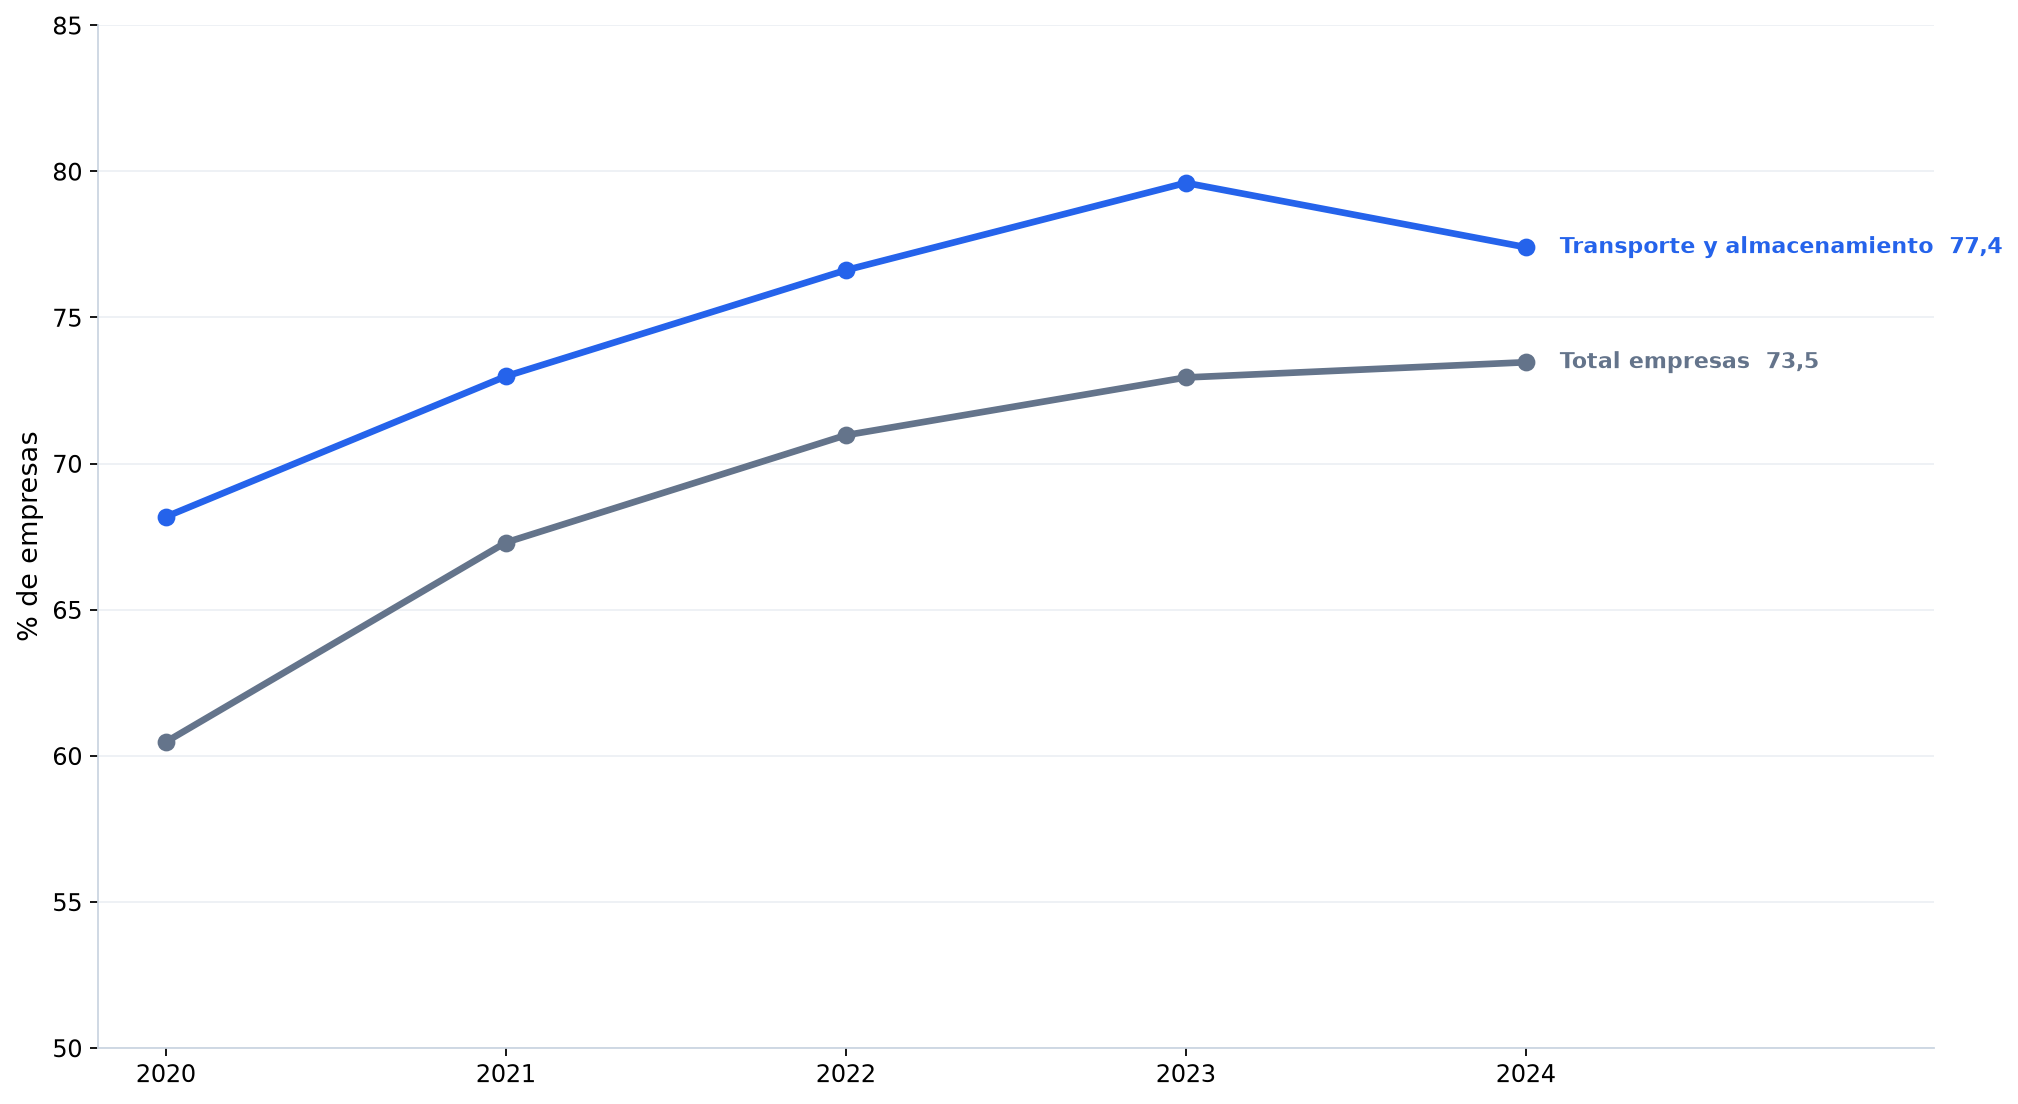

In [13]:
variable_formacion = "EMPRESAS QUE PROPORCIONAN FORMACIÓN - TOTAL"

contexto_formacion = (
    df_base[
        (df_base["tabla_base"].eq("EAL-17"))
        & (df_base["variable"].eq(variable_formacion))
        & (df_base["categoria_norm"].isin(["TOTAL", SECTOR_OBJETIVO]))
    ]
    [["anio", "categoria", "porcentaje"]]
    .copy()
)

contexto_formacion["serie"] = contexto_formacion["categoria"].replace({
    "TOTAL": "Total empresas",
    "Transporte y almacenamiento": "Transporte y almacenamiento",
})

contexto_pivot = contexto_formacion.pivot(
    index="anio",
    columns="serie",
    values="porcentaje"
)

display(contexto_pivot.round(1))


# ============================================================
# GRÁFICO
# ============================================================

fig, ax = plt.subplots(figsize=(13, 7), dpi=160)

preparar_ax(
    ax,
    xlabel="",
    ylabel="% de empresas",
    grid="y",
    mostrar_xlabel=False,
    mostrar_ylabel=True
)

colores = {
    "Transporte y almacenamiento": PALETA["azul"],
    "Total empresas": PALETA["gris"],
}

for columna, color in colores.items():
    ax.plot(
        contexto_pivot.index,
        contexto_pivot[columna],
        marker="o",
        linewidth=3,
        markersize=7,
        color=color
    )

    valor_final = contexto_pivot.loc[2024, columna]

    etiquetar_final(
        ax,
        x=2024,
        y=valor_final,
        texto=f"{columna}  {formato_pct(valor_final)}",
        color=color,
        dx=0.10
    )

ax.set_xlim(2019.8, 2025.2)
ax.set_ylim(50, 85)
ax.set_xticks(ANIOS)

plt.tight_layout()
plt.show()

In [14]:
def tabla_exacta(tabla):
    return df_base[df_base["tabla"].astype(str).str.upper().eq(tabla.upper())].copy()


def serie_prioridad(tabla, etiqueta):
    base = tabla_exacta(tabla)
    out = (
        base[base["variable_norm"].isin(["BASTANTE", "MUCHO"])]
        .groupby(["anio", "categoria"], as_index=False)["porcentaje"]
        .sum()
        .rename(columns={"porcentaje": "prioridad_pct"})
    )
    out["benchmark"] = etiqueta
    return out


def serie_formacion(tabla, variable, etiqueta):
    base = tabla_exacta(tabla).assign(variable_clave=lambda d: d["variable"].map(clave_texto))
    out = base[base["variable_clave"].eq(clave_texto(variable))][["anio", "categoria", "porcentaje"]].copy()
    out = out.rename(columns={"porcentaje": "formacion_pct"})
    out["benchmark"] = etiqueta
    return out

prioridad_competencias = pd.concat([
    serie_prioridad("EAL-16", "Total empresas"),
    serie_prioridad("EAL-16C", "Más de 499 trabajadores"),
    serie_prioridad("EAL-16F", "Servicios"),
], ignore_index=True)

formacion_competencias = pd.concat([
    serie_formacion("EAL-20", "TOTAL", "Total empresas"),
    serie_formacion("EAL-20", "MÁS DE 499 TRABAJADORES", "Más de 499 trabajadores"),
    serie_formacion("EAL-21", "SERVICIOS", "Servicios"),
], ignore_index=True)

for frame in [prioridad_competencias, formacion_competencias]:
    frame["clave_competencia"] = frame["categoria"].map(clave_texto).str.replace(
        "COMPETENCIAS TECNICAS, PRACTICAS Y OTRAS ESPECIFICAS DEL PUESTO DE TRABAJO",
        "TECNICAS ESPECIFICAS DEL PUESTO DE TRABAJO",
        regex=False,
    )

print("Prioridad:", prioridad_competencias.shape)
print("Formación:", formacion_competencias.shape)

Prioridad: (120, 5)
Formación: (168, 5)


## Paso 2. Situación final 2024

**Gráfico 2**

1. **Tablas base:** EAL-16c/EAL-16f para prioridad; EAL-20/EAL-21 para formación efectiva.
2. **Filtro:** 2024; empresas de más de 499 trabajadores y sector Servicios.
3. **Lectura de negocio:** muestra la posición relativa de las competencias en un entorno comparable por tamaño y en el benchmark sectorial disponible.
4. **Cautela:** no existe detalle suficiente de Transporte y almacenamiento en las tablas de competencias. Servicios es un benchmark, no un sustituto exacto. Los paneles de prioridad y formación tienen denominadores diferentes y no deben restarse como si fueran la misma métrica.

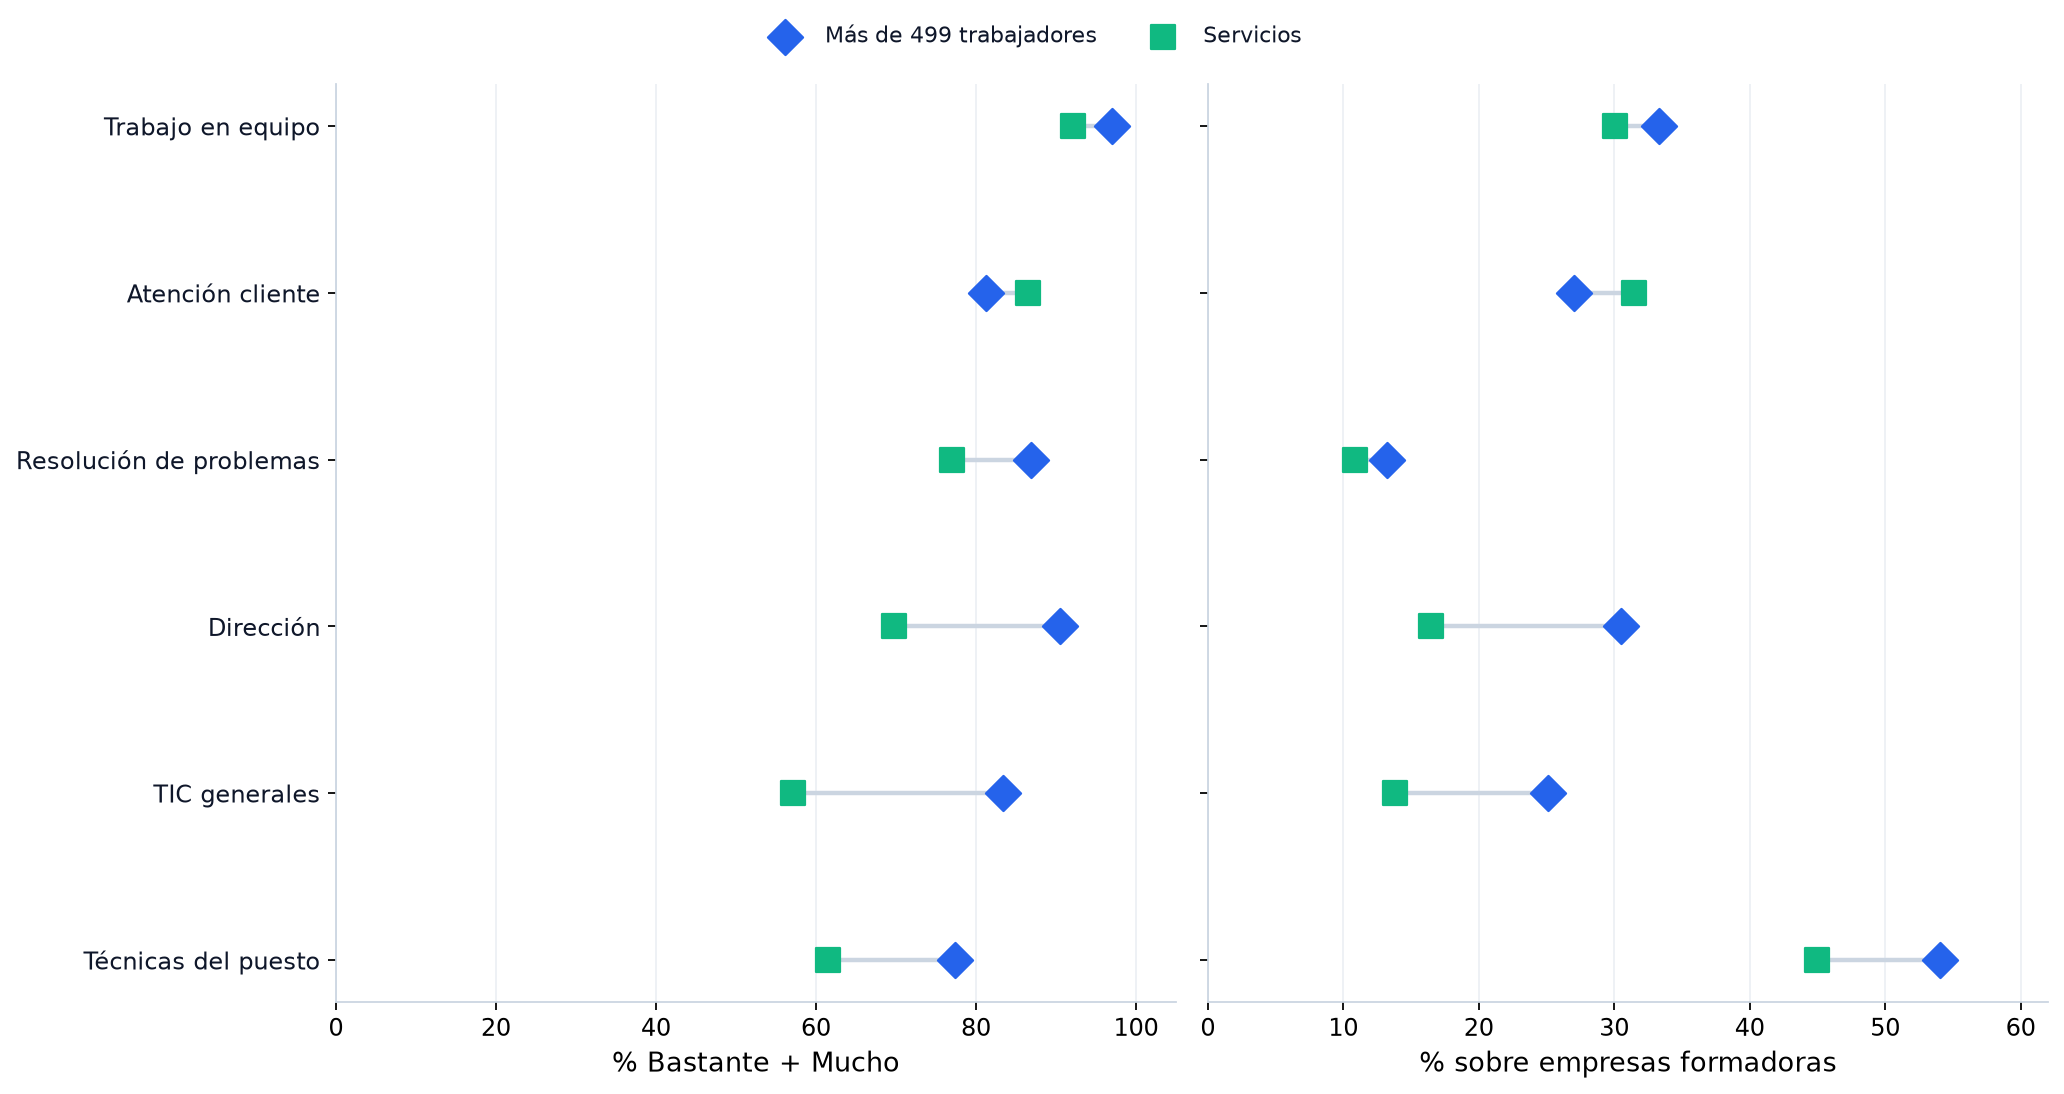

benchmark,Más de 499 trabajadores,Servicios
clave_competencia,,
DE ATENCION AL PUBLICO/ TRATO A CLIENTES,81.3,86.5
DE DIRECCION,90.5,69.8
"DE RESOLUCION DE PROBLEMAS (LOCALIZACION DE PROBLEMAS O FALLOS, ANALISIS DE SUS CAUSAS Y BUSQUEDA DE SOLUCIONES)",86.8,77.0
DE TRABAJO EN EQUIPO,97.0,92.1
GENERALES DE TECNOLOGIAS DE LA INFORMACION,83.4,57.1
TECNICAS ESPECIFICAS DEL PUESTO DE TRABAJO,77.3,61.5


benchmark,Más de 499 trabajadores,Servicios
clave_competencia,,
DE ATENCION AL PUBLICO/ TRATO A CLIENTES,27.1,31.5
DE DIRECCION,30.5,16.4
"DE RESOLUCION DE PROBLEMAS (LOCALIZACION DE PROBLEMAS O FALLOS, ANALISIS DE SUS CAUSAS Y BUSQUEDA DE SOLUCIONES)",13.2,10.9
DE TRABAJO EN EQUIPO,33.3,30.1
GENERALES DE TECNOLOGIAS DE LA INFORMACION,25.1,13.8
TECNICAS ESPECIFICAS DEL PUESTO DE TRABAJO,54.0,45.0


In [15]:
competencias_slide = [
    "TECNICAS ESPECIFICAS DEL PUESTO DE TRABAJO",
    "DE TRABAJO EN EQUIPO",
    "DE ATENCION AL PUBLICO/ TRATO A CLIENTES",
    "DE RESOLUCION DE PROBLEMAS (LOCALIZACION DE PROBLEMAS O FALLOS, ANALISIS DE SUS CAUSAS Y BUSQUEDA DE SOLUCIONES)",
    "DE DIRECCION",
    "GENERALES DE TECNOLOGIAS DE LA INFORMACION",
]

prioridad_2024 = prioridad_competencias[
    prioridad_competencias["anio"].eq(2024)
    & prioridad_competencias["benchmark"].isin(["Más de 499 trabajadores", "Servicios"])
    & prioridad_competencias["clave_competencia"].isin(competencias_slide)
].pivot(
    index="clave_competencia",
    columns="benchmark",
    values="prioridad_pct"
)

formacion_2024 = formacion_competencias[
    formacion_competencias["anio"].eq(2024)
    & formacion_competencias["benchmark"].isin(["Más de 499 trabajadores", "Servicios"])
    & formacion_competencias["clave_competencia"].isin(competencias_slide)
].pivot(
    index="clave_competencia",
    columns="benchmark",
    values="formacion_pct"
)

orden = prioridad_2024.mean(axis=1).sort_values().index

labels = {
    clave_texto(k).replace(
        "COMPETENCIAS TECNICAS, PRACTICAS Y OTRAS ESPECIFICAS DEL PUESTO DE TRABAJO",
        "TECNICAS ESPECIFICAS DEL PUESTO DE TRABAJO"
    ): corto(k)
    for k in NOMBRES_CORTOS
}


# ============================================================
# GRÁFICO
# ============================================================


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 7), dpi=160,
    sharey=True
)

graficos = [
    (
        axes[0],
        prioridad_2024.loc[orden],
        "% Bastante + Mucho"
    ),
    (
        axes[1],
        formacion_2024.reindex(orden),
        "% sobre empresas formadoras"
    ),
]

colores_benchmark = {
    "Más de 499 trabajadores": PALETA["azul"],
    "Servicios": PALETA["verde"],
}

marcadores_benchmark = {
    "Más de 499 trabajadores": "D",
    "Servicios": "s",
}

for ax, data, xlabel in graficos:
    preparar_ax(
        ax,
        xlabel=xlabel,
        ylabel="",
        grid=None,
        mostrar_xlabel=True,
        mostrar_ylabel=False
    )

    # Grid vertical suave, más adecuado para este tipo de gráfico horizontal
    ax.grid(
        axis="x",
        color=PALETA["gris_claro"],
        alpha=0.35,
        linewidth=0.8
    )

    y = np.arange(len(data))

    # Línea de diferencia entre benchmarks
    for i, (_, row) in enumerate(data.iterrows()):
        vals = row.dropna().values

        if len(vals) > 1:
            ax.plot(
                [vals.min(), vals.max()],
                [i, i],
                color=PALETA["gris_claro"],
                linewidth=2,
                zorder=0
            )

    # Puntos
    for benchmark, color in colores_benchmark.items():
        ax.scatter(
            data[benchmark],
            y,
            s=125,
            color=color,
            marker=marcadores_benchmark[benchmark],
            label=benchmark,
            zorder=3
        )

    ax.set_xlim(0, max(data.max()) + 8)


# Etiquetas del eje Y
axes[0].set_yticks(np.arange(len(orden)))
axes[0].set_yticklabels(
    ["\n".join(wrap(labels.get(k, k.title()), 23)) for k in orden],
    color=PALETA["texto"]
)

# Ocultar etiquetas Y en el segundo gráfico
axes[1].tick_params(axis="y", labelleft=False)

# Leyenda común
handles, legend_labels = axes[0].get_legend_handles_labels()

leyenda_comun(
    fig,
    handles,
    legend_labels,
    y=0.98,
    ncol=2
)

# Eliminar leyendas individuales
for ax in axes:
    legend = ax.get_legend()
    if legend:
        legend.remove()

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


display(prioridad_2024.round(1))
display(formacion_2024.round(1))

## Paso 3. Propuesta para RapidExpress

**Gráfico 3**

1. **Tablas base:** EAL-16 y EAL-20.
2. **Filtro:** 2024, Total empresas; prioridad `Bastante + Mucho` y formación efectiva.
3. **Lectura de negocio:** posiciona competencias para priorizar. La zona superior izquierda reúne competencias declaradas como importantes pero con menor presencia relativa en la formación observada.
4. **Cautela:** los ejes tienen denominadores diferentes: EAL-16 usa total de empresas y EAL-20 empresas formadoras. Es un mapa descriptivo de posicionamiento, no una brecha causal ni un test de déficit.

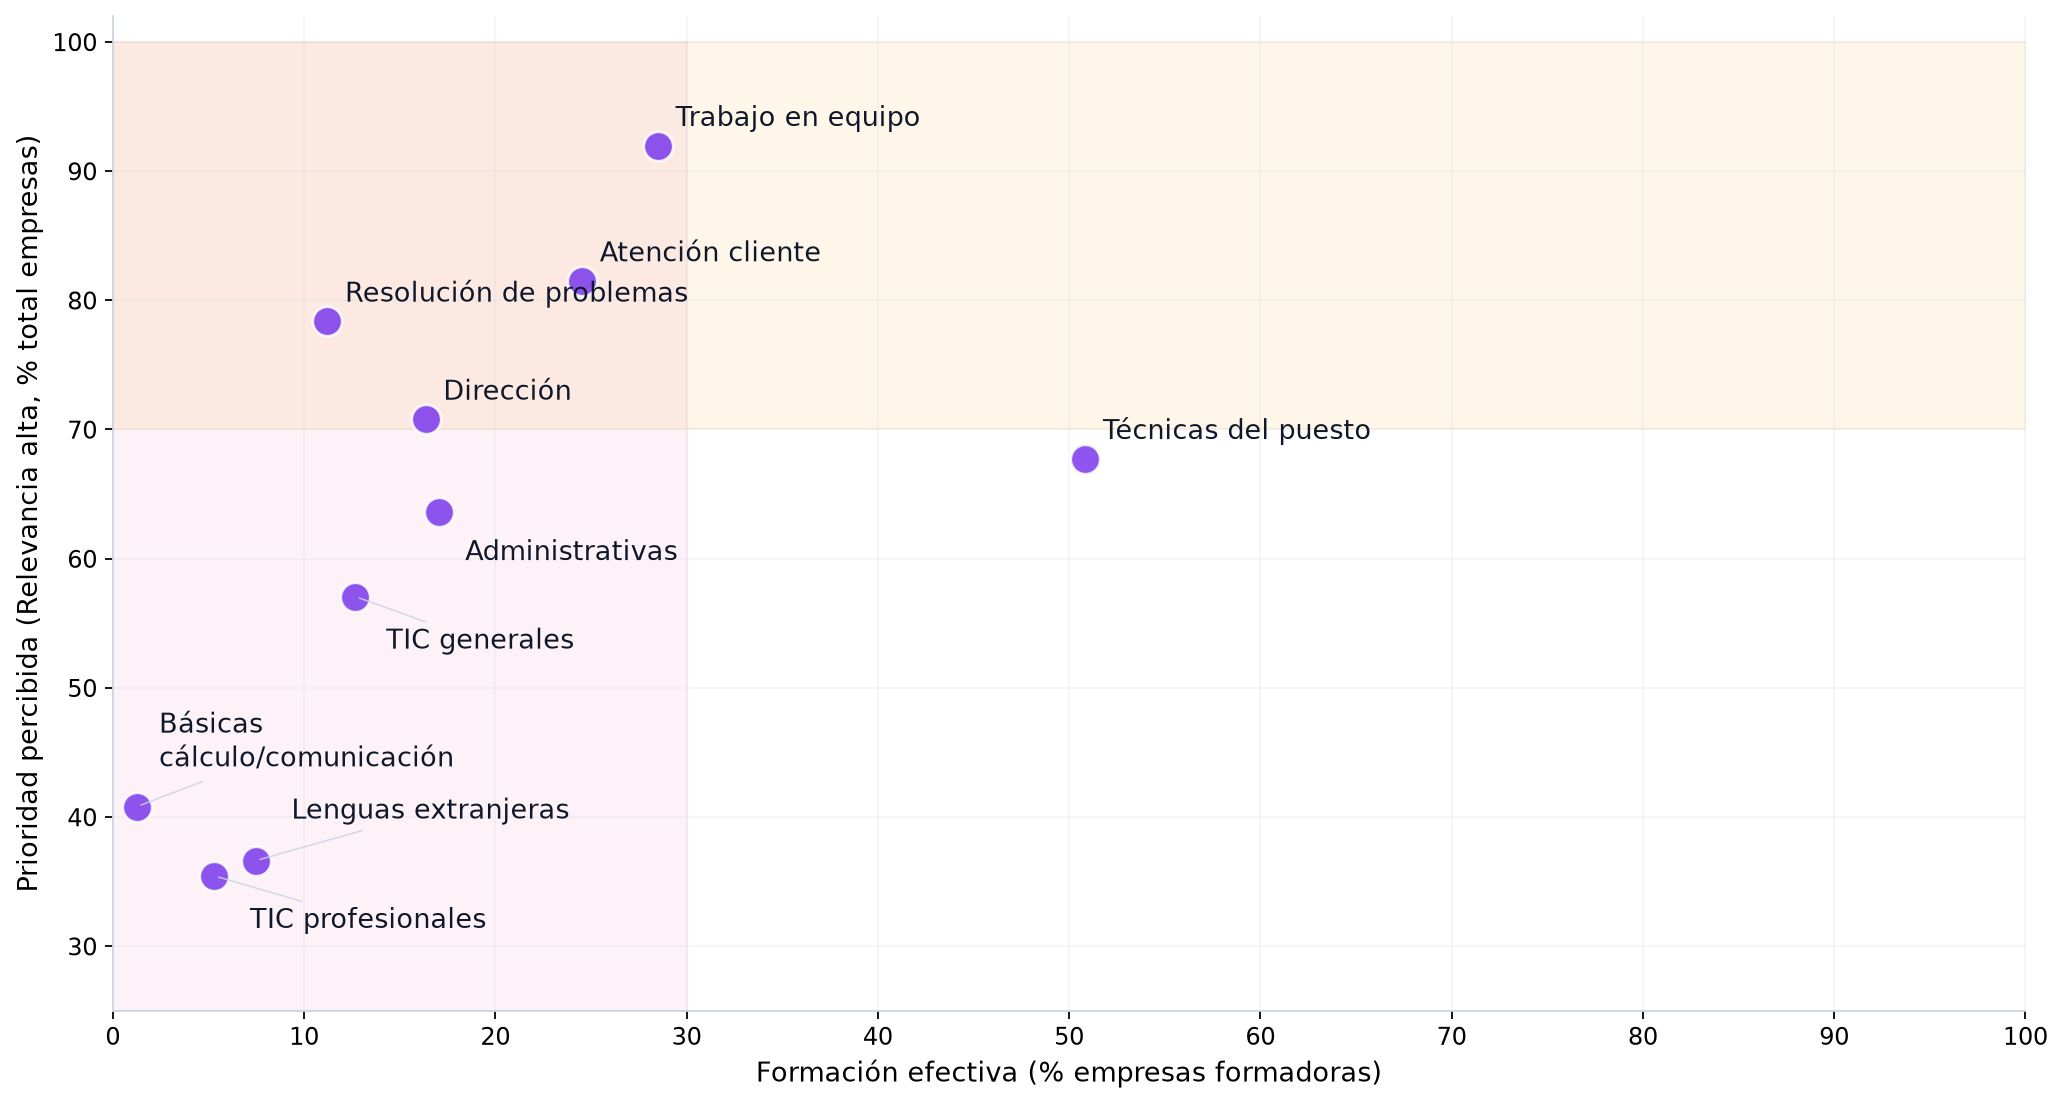

,categoria,clave_competencia,prioridad_pct,formacion_pct,competencia_corta
6,De trabajo en equipo,DE TRABAJO EN EQUIPO,92.0,28.5,Trabajo en equipo
3,De atención al público/ trato a clientes,DE ATENCION AL PUBLICO/ TRATO A CLIENTES,81.5,24.5,Atención cliente
5,"De resolución de problemas (localización de problemas o fallos, análisis de sus causas y búsqueda de soluciones)","DE RESOLUCION DE PROBLEMAS (LOCALIZACION DE PROBLEMAS O FALLOS, ANALISIS DE SUS CAUSAS Y BUSQUEDA DE SOLUCIONES)",78.4,11.2,Resolución de problemas
4,De dirección,DE DIRECCION,70.8,16.3,Dirección
2,"Competencias técnicas, prácticas y otras específicas del puesto de trabajo",TECNICAS ESPECIFICAS DEL PUESTO DE TRABAJO,67.7,50.8,Técnicas del puesto
0,Administrativas de oficina,ADMINISTRATIVAS DE OFICINA,63.6,17.0,Administrativas
8,Generales de tecnologías de la información,GENERALES DE TECNOLOGIAS DE LA INFORMACION,57.1,12.7,TIC generales
1,Básicas de cálculo y/o comunicación oral o escrita,BASICAS DE CALCULO Y/O COMUNICACION ORAL O ESCRITA,40.8,1.3,Básicas cálculo/comunicación
7,En lenguas extranjeras,EN LENGUAS EXTRANJERAS,36.6,7.5,Lenguas extranjeras
9,Profesionales de tecnologías de la información,PROFESIONALES DE TECNOLOGIAS DE LA INFORMACION,35.4,5.3,TIC profesionales


In [16]:
prioridad_total_2024 = prioridad_competencias[
    prioridad_competencias["anio"].eq(2024)
    & prioridad_competencias["benchmark"].eq("Total empresas")
][["categoria", "clave_competencia", "prioridad_pct"]]

formacion_total_2024 = formacion_competencias[
    formacion_competencias["anio"].eq(2024)
    & formacion_competencias["benchmark"].eq("Total empresas")
][["clave_competencia", "formacion_pct"]]

mapa_decision = prioridad_total_2024.merge(
    formacion_total_2024,
    on="clave_competencia",
    how="inner"
)

mapa_decision["competencia_corta"] = mapa_decision["categoria"].map(corto)

fig, ax = plt.subplots(figsize=(13, 7), dpi=160)

preparar_ax(
    ax,
    xlabel="Formación efectiva (% empresas formadoras)",
    ylabel="Prioridad percibida (Relevancia alta, % total empresas)",
    grid="both"
)

# Limits first
ax.set_xlim(0, 100)
ax.set_ylim(25, 102)



# Compute where y = 100 is in axis fraction
y_min, y_max = ax.get_ylim()
y_frac_100 = (100 - y_min) / (y_max - y_min)

# Red area: only up to y = 100
ax.axvspan(
    0, 30,
    ymin=0, ymax=y_frac_100,
    color=PALETA["rosa"],
    alpha=0.06,
    zorder=0
)

# Orange area: from y = 70 to y = 100
ax.axhspan(
    70, 100,
    color=PALETA["ambar"],
    alpha=0.09,
    zorder=0
)

ax.set_xticks(np.arange(0, 101, 10))

# Points
ax.scatter(
    mapa_decision["formacion_pct"],
    mapa_decision["prioridad_pct"],
    s=175,
    color=PALETA["morado"],
    alpha=0.86,
    edgecolor="white",
    linewidth=1.2,
    zorder=3,
)

# Manual label offsets
offsets_labels = {
    "Básicas cálculo/comunicación": (10, 14),
    "Lenguas extranjeras": (16, 16),
    "TIC profesionales": (16, -14),
    "TIC generales": (14, -14),
    "Administrativas": (12, -12),
    "Otras": (10, -10),
}

for _, row in mapa_decision.iterrows():
    etiqueta = row["competencia_corta"]
    dx, dy = offsets_labels.get(etiqueta, (8, 6))

    ax.annotate(
        "\n".join(wrap(etiqueta, 26)),
        xy=(row["formacion_pct"], row["prioridad_pct"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=12,
        color=PALETA["texto"],
        ha="left" if dx >= 0 else "right",
        va="bottom" if dy >= 0 else "top",
        arrowprops=dict(
            arrowstyle="-",
            color=PALETA["gris_claro"],
            lw=0.7,
            alpha=0.85
        ) if abs(dx) > 12 or abs(dy) > 12 else None,
        zorder=4
    )

plt.tight_layout()
plt.show()

display(
    mapa_decision.sort_values(
        ["prioridad_pct", "formacion_pct"],
        ascending=[False, True]
    ).round(1)
)

## Recomendación final

Los datos sugieren que RapidExpress debería mantener las competencias técnicas del puesto como base, pero orientar el siguiente esfuerzo formativo hacia:

- resolución de problemas e incidencias operativas;
- trabajo en equipo y coordinación entre áreas;
- atención al cliente;
- adaptación digital y uso general de tecnologías;
- dirección y mandos intermedios en una empresa de gran tamaño.

La recomendación no es “formar más” de forma genérica, sino **equilibrar la formación técnica con competencias transversales críticas para la operación**. Esta lectura es descriptiva y debe combinarse con los datos internos de RapidExpress para convertirla en un plan de formación concreto.

## Análisis complementario

Estos gráficos recuperan los visuales de la versión anterior. No sustituyen los tres recomendados para slides: sirven para profundizar, responder preguntas y apoyar la conversación posterior.

En el contraste prioridad-formación no se calcula una brecha estadística porque los denominadores de EAL-16 y EAL-20 son diferentes.

### Complementario A. Contraste visual prioridad-formación

El dumbbell permite ver la distancia visual entre la prioridad declarada y la presencia de cada competencia en la formación. Debe interpretarse como **contraste de posición**, no como déficit en puntos porcentuales.

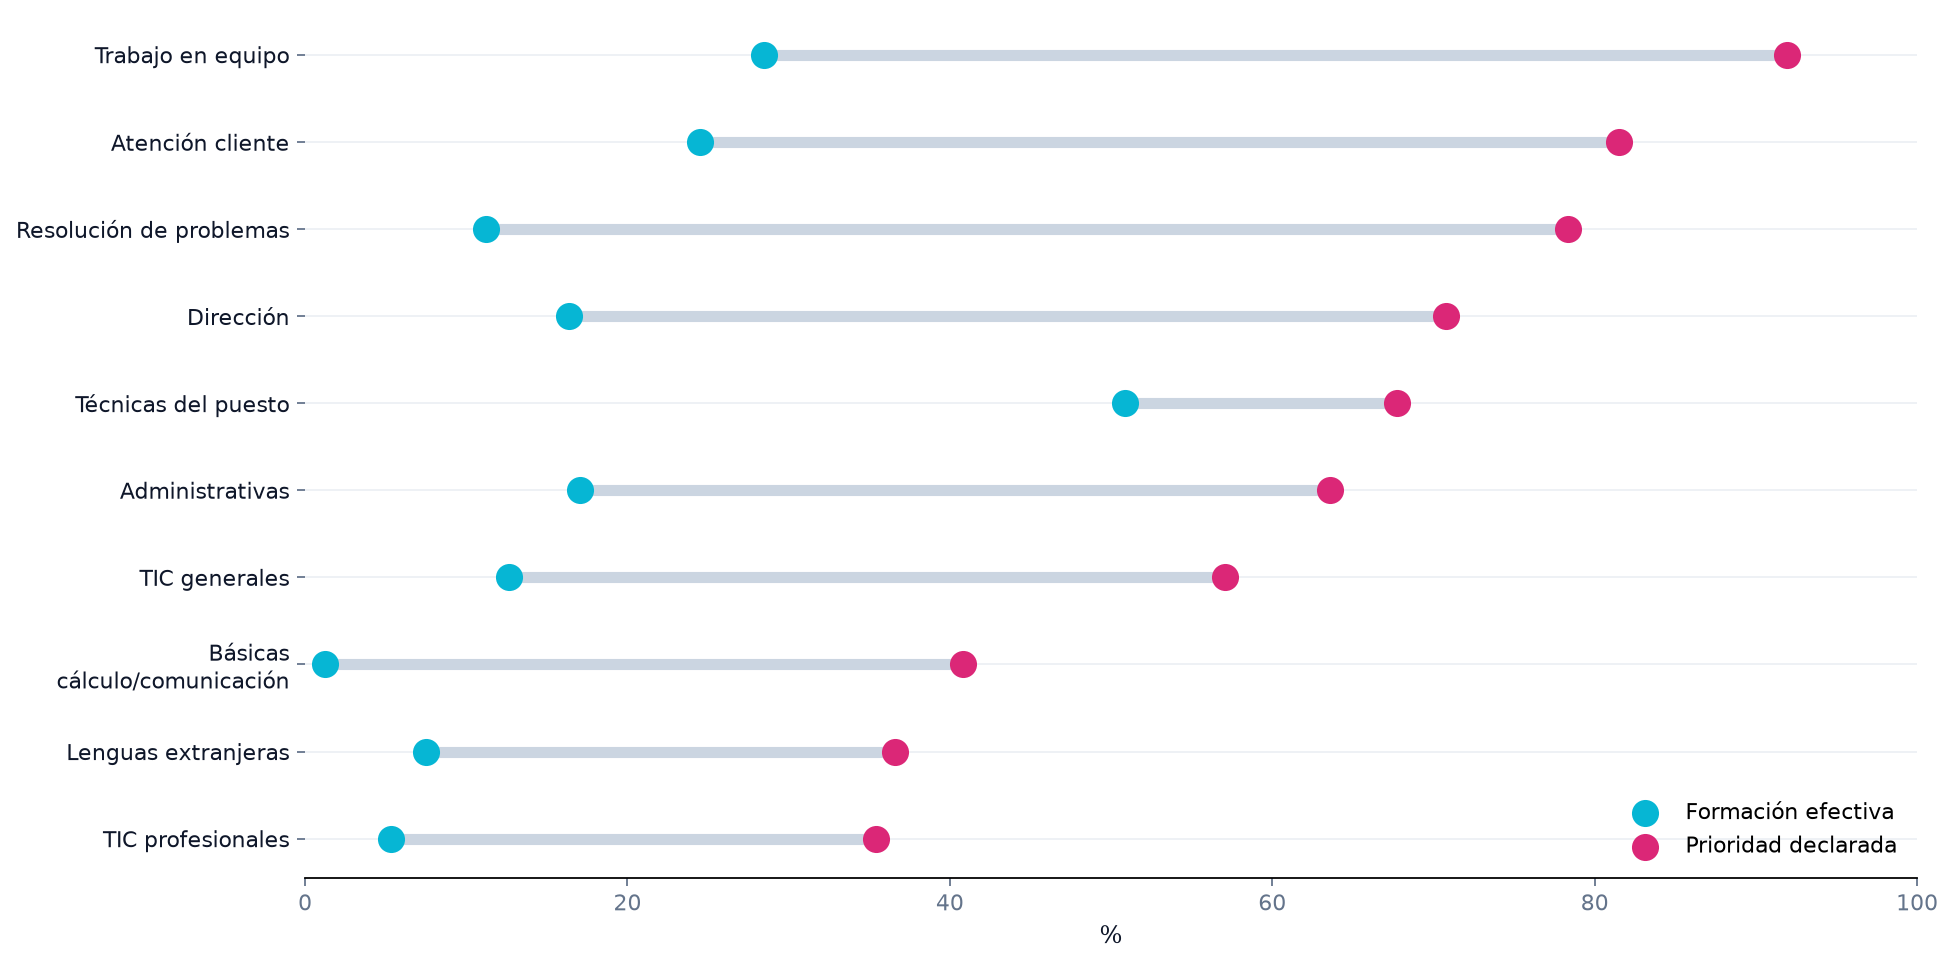

In [17]:
plot_contraste = mapa_decision.sort_values("prioridad_pct").copy()
y = np.arange(len(plot_contraste))

fig, ax = plt.subplots(figsize=(13, 7), dpi=160)
preparar_figura(
    ax,
    "",
    "",
)
for i, (_, row) in enumerate(plot_contraste.iterrows()):
    ax.plot(
        [row["formacion_pct"], row["prioridad_pct"]],
        [i, i],
        color=PALETA["gris_claro"],
        linewidth=5,
        solid_capstyle="round",
        zorder=1,
    )
ax.scatter(plot_contraste["formacion_pct"], y, s=125, color=PALETA["cyan"], label="Formación efectiva", zorder=3)
ax.scatter(plot_contraste["prioridad_pct"], y, s=125, color=PALETA["rosa"], label="Prioridad declarada", zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(envolver(plot_contraste["categoria"], 25), color=PALETA["texto"])
ax.set_xlim(0, 100)
ax.set_xlabel("%", color=PALETA["texto"])
ax.legend(frameon=False, loc="lower right")
plt.show()

### Complementario B. Perfil formativo: empresa grande vs Servicios

Este gráfico sí compara la misma clase de indicador: porcentaje de empresas formadoras que formaron en cada competencia. Permite observar especializaciones relativas del proxy de RapidExpress frente al benchmark Servicios.

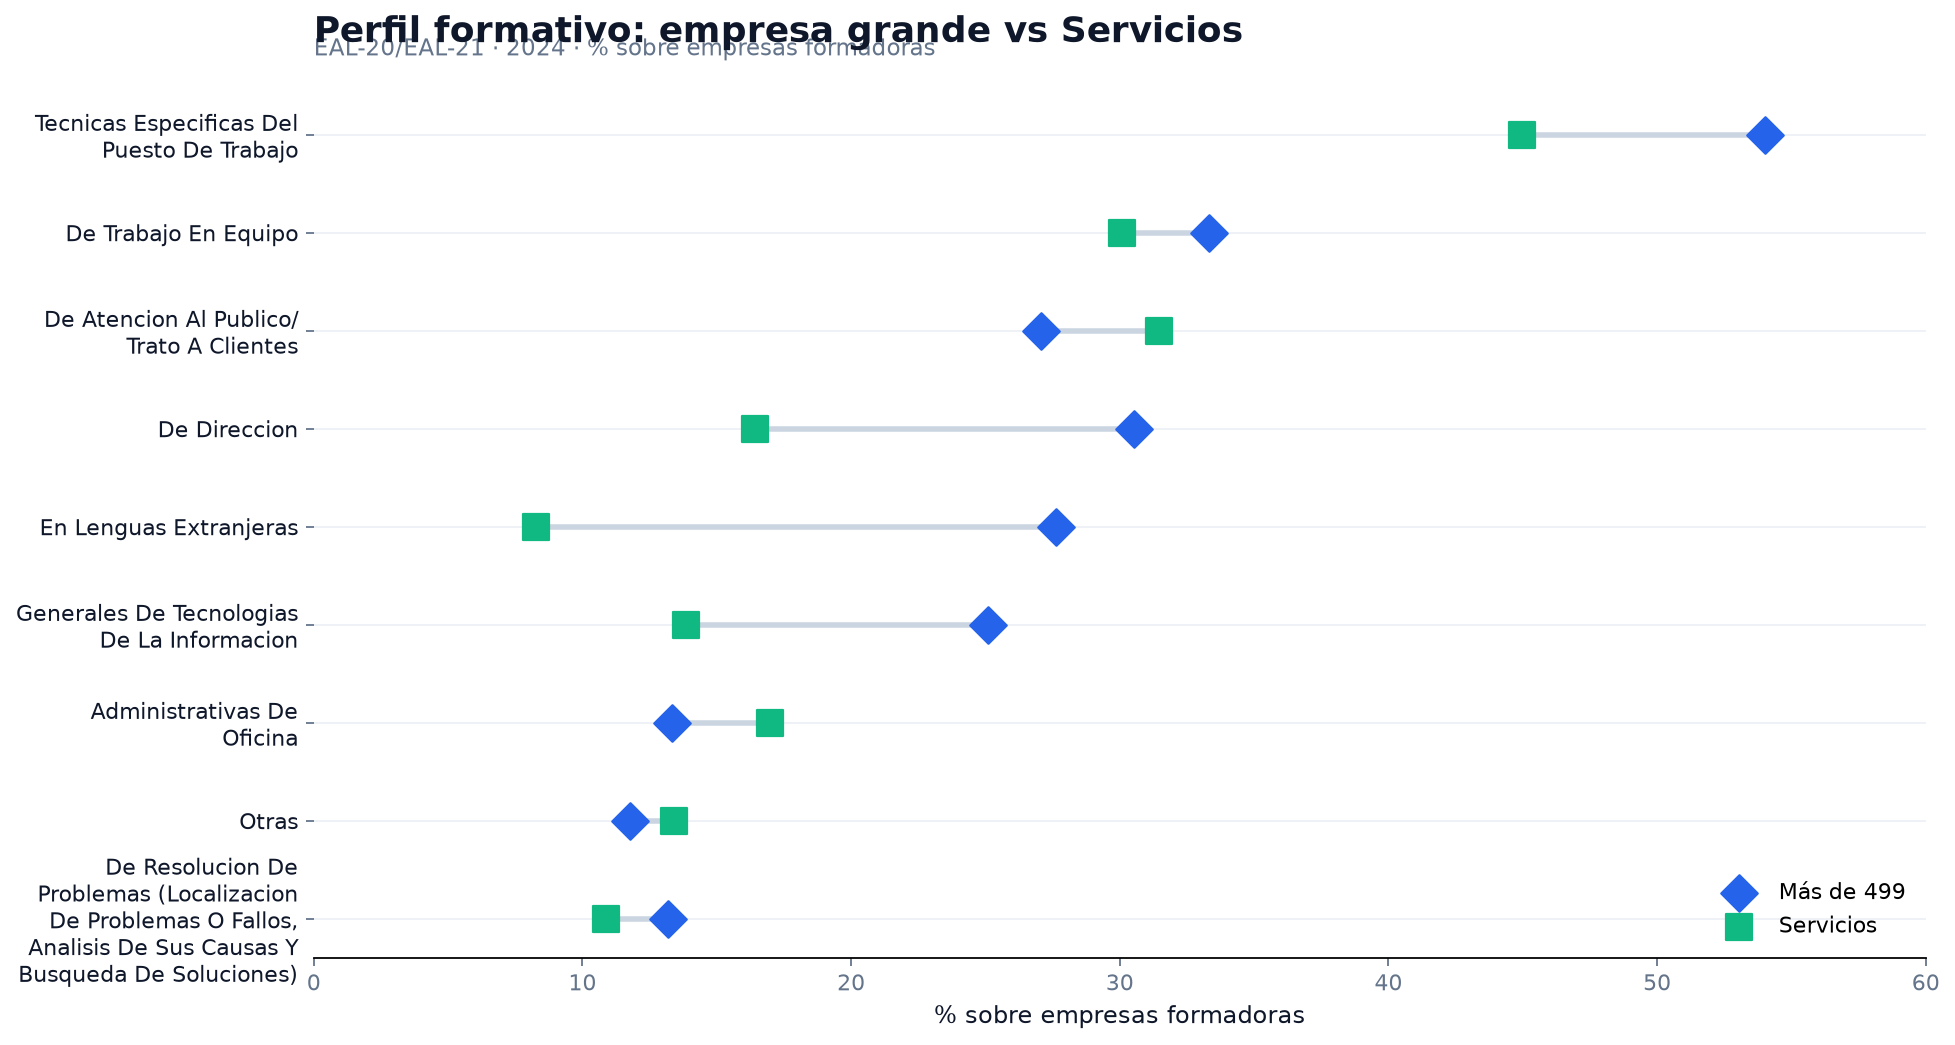

benchmark,Más de 499 trabajadores,Servicios,diferencial_mas499_vs_servicios_pp
clave_competencia,,,
EN LENGUAS EXTRANJERAS,27.6,8.3,19.4
DE DIRECCION,30.5,16.4,14.1
GENERALES DE TECNOLOGIAS DE LA INFORMACION,25.1,13.8,11.3
TECNICAS ESPECIFICAS DEL PUESTO DE TRABAJO,54.0,45.0,9.0
PROFESIONALES DE TECNOLOGIAS DE LA INFORMACION,12.7,5.8,6.9
DE TRABAJO EN EQUIPO,33.3,30.1,3.3
"DE RESOLUCION DE PROBLEMAS (LOCALIZACION DE PROBLEMAS O FALLOS, ANALISIS DE SUS CAUSAS Y BUSQUEDA DE SOLUCIONES)",13.2,10.9,2.3
BASICAS DE CALCULO Y/O COMUNICACION ORAL O ESCRITA,2.8,1.3,1.6
OTRAS,11.8,13.4,-1.6


In [18]:
perfil_2024 = formacion_competencias[
    formacion_competencias["anio"].eq(2024)
    & formacion_competencias["benchmark"].isin(["Más de 499 trabajadores", "Servicios"])
].pivot(index="clave_competencia", columns="benchmark", values="formacion_pct")

perfil_2024["diferencial_mas499_vs_servicios_pp"] = (
    perfil_2024["Más de 499 trabajadores"] - perfil_2024["Servicios"]
)
perfil_plot = (
    perfil_2024.assign(max_relevancia=perfil_2024[["Más de 499 trabajadores", "Servicios"]].max(axis=1))
    .sort_values("max_relevancia", ascending=False)
    .head(9)
    .sort_values("max_relevancia")
)

fig, ax = plt.subplots(figsize=(13, 7), dpi=160)
preparar_figura(
    ax,
    "Perfil formativo: empresa grande vs Servicios",
    "EAL-20/EAL-21 · 2024 · % sobre empresas formadoras",
)
y = np.arange(len(perfil_plot))
for i, (_, row) in enumerate(perfil_plot.iterrows()):
    ax.plot(
        [row["Servicios"], row["Más de 499 trabajadores"]],
        [i, i],
        color=PALETA["gris_claro"],
        linewidth=2.5,
        zorder=1,
    )
ax.scatter(perfil_plot["Más de 499 trabajadores"], y, s=135, color=PALETA["azul"], marker="D", label="Más de 499", zorder=3)
ax.scatter(perfil_plot["Servicios"], y, s=135, color=PALETA["verde"], marker="s", label="Servicios", zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(["\n".join(wrap(k.title(), 25)) for k in perfil_plot.index], color=PALETA["texto"])
ax.set_xlim(0, 60)
ax.set_xlabel("% sobre empresas formadoras", color=PALETA["texto"])
ax.legend(frameon=False, loc="lower right")
plt.show()

display(
    perfil_2024.sort_values("diferencial_mas499_vs_servicios_pp", ascending=False)
    .round(1)
)

### Complementario C. Evolución de competencias formadas en Servicios

Permite ver el momentum descriptivo entre 2020 y 2024. No implica que sean las mismas empresas ni que el cambio sea estadísticamente significativo.

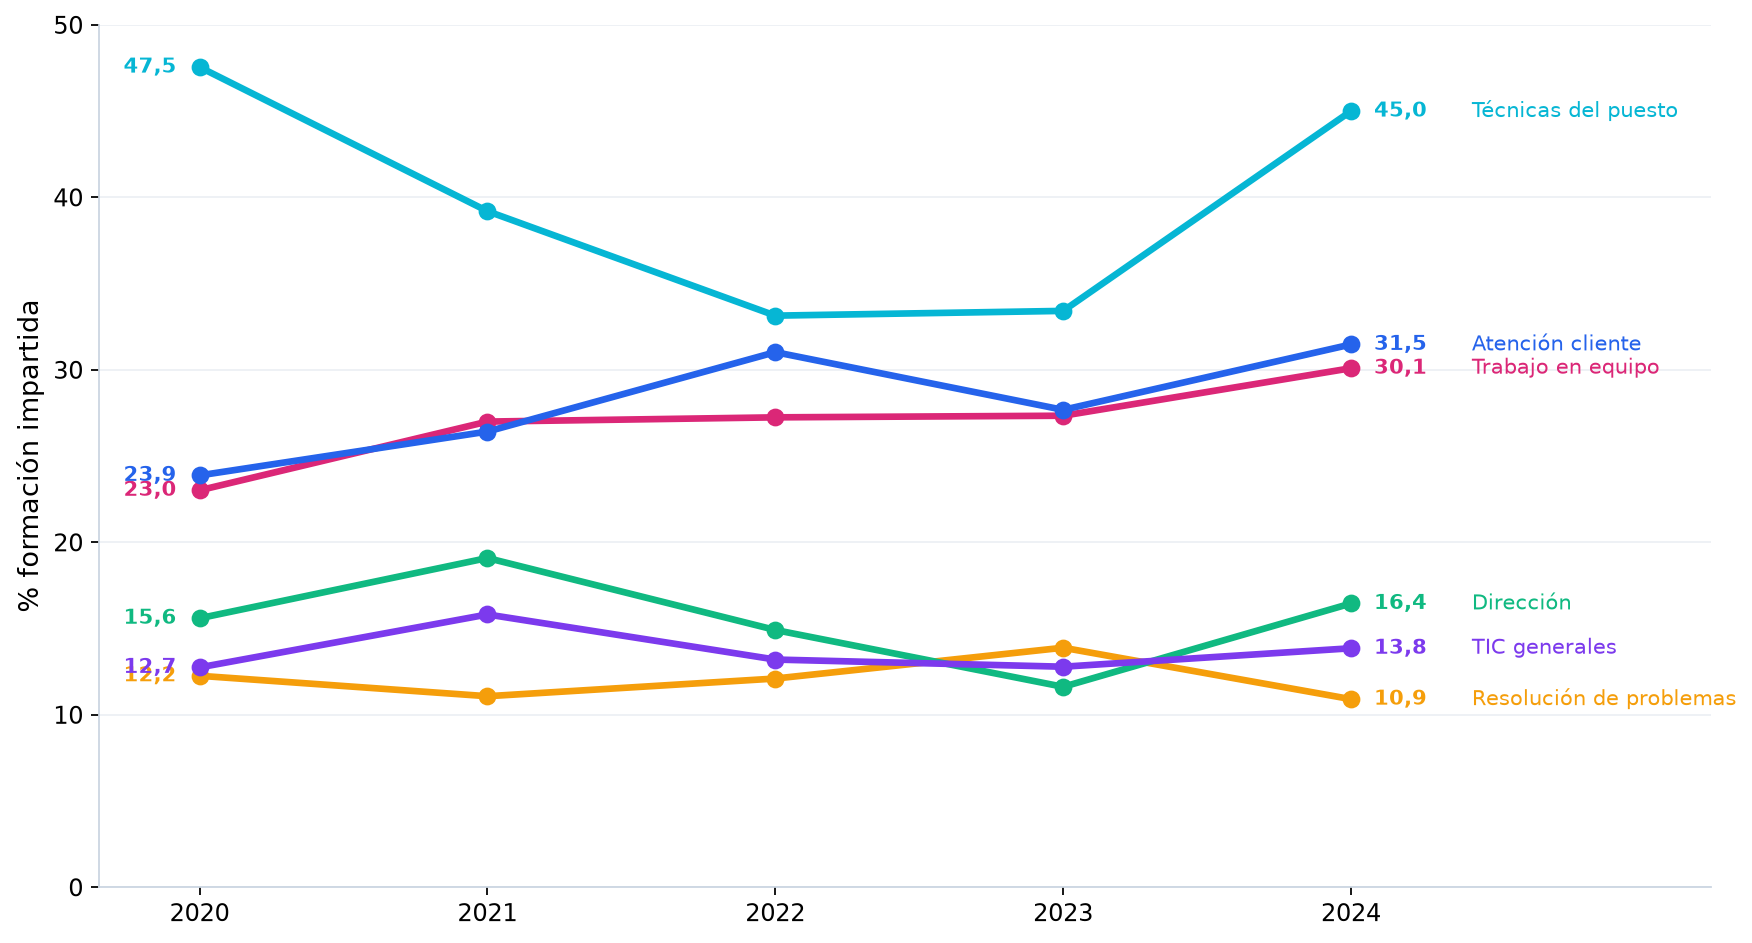

anio,2020,2021,2022,2023,2024,var_2020_2024_pp
clave_competencia,,,,,,
DE ATENCION AL PUBLICO/ TRATO A CLIENTES,23.9,26.4,31.0,27.7,31.5,7.6
DE DIRECCION,15.6,19.1,14.9,11.6,16.4,0.9
"DE RESOLUCION DE PROBLEMAS (LOCALIZACION DE PROBLEMAS O FALLOS, ANALISIS DE SUS CAUSAS Y BUSQUEDA DE SOLUCIONES)",12.2,11.1,12.1,13.9,10.9,-1.4
DE TRABAJO EN EQUIPO,23.0,27.0,27.2,27.3,30.1,7.1
GENERALES DE TECNOLOGIAS DE LA INFORMACION,12.7,15.8,13.2,12.8,13.8,1.1
TECNICAS ESPECIFICAS DEL PUESTO DE TRABAJO,47.5,39.2,33.1,33.4,45.0,-2.5


In [19]:
# ============================================================
# MOMENTUM EN SERVICIOS: QUÉ COMPETENCIAS GANAN PESO
# ============================================================

competencias_foco = {
    "TECNICAS ESPECIFICAS DEL PUESTO DE TRABAJO": "Técnicas del puesto",
    "DE TRABAJO EN EQUIPO": "Trabajo en equipo",
    "DE ATENCION AL PUBLICO/ TRATO A CLIENTES": "Atención cliente",
    "DE RESOLUCION DE PROBLEMAS (LOCALIZACION DE PROBLEMAS O FALLOS, ANALISIS DE SUS CAUSAS Y BUSQUEDA DE SOLUCIONES)": "Resolución de problemas",
    "DE DIRECCION": "Dirección",
    "GENERALES DE TECNOLOGIAS DE LA INFORMACION": "TIC generales",
}

evolucion_servicios = formacion_competencias[
    formacion_competencias["benchmark"].eq("Servicios")
    & formacion_competencias["clave_competencia"].isin(competencias_foco)
].copy()

# Colores fijos por competencia
colores_competencias = {
    "Técnicas del puesto": PALETA["principal"] if "principal" in PALETA else PALETA["cyan"],
    "Trabajo en equipo": PALETA["secundario"] if "secundario" in PALETA else PALETA["rosa"],
    "Atención cliente": PALETA["azul"] if "azul" in PALETA else PALETA["gris"],
    "Resolución de problemas": PALETA["alerta"] if "alerta" in PALETA else PALETA["ambar"],
    "Dirección": PALETA["verde"] if "verde" in PALETA else PALETA["gris"],
    "TIC generales": PALETA["morado"] if "morado" in PALETA else PALETA["neutro"],
}

fig, ax = plt.subplots(figsize=(13, 7), dpi=160)

preparar_ax(
    ax,
    xlabel="",
    ylabel="% formación impartida",
    grid="y",
    mostrar_xlabel=False,
    mostrar_ylabel=True
)

for clave in competencias_foco:
    data = evolucion_servicios[
        evolucion_servicios["clave_competencia"].eq(clave)
    ].sort_values("anio")

    if data.empty:
        continue

    etiqueta = competencias_foco[clave]
    color = colores_competencias[etiqueta]

    ax.plot(
        data["anio"],
        data["formacion_pct"],
        marker="o",
        linewidth=3,
        markersize=7,
        color=color
    )

    primero = data.iloc[0]
    ultimo = data.iloc[-1]

    # Porcentaje inicial
    ax.text(
        primero["anio"] - 0.08,
        primero["formacion_pct"],
        formato_pct(primero["formacion_pct"]),
        va="center",
        ha="right",
        fontsize=9.5,
        fontweight="bold",
        color=color,
        clip_on=False
    )

    # Porcentaje final
    ax.text(
        ultimo["anio"] + 0.08,
        ultimo["formacion_pct"],
        formato_pct(ultimo["formacion_pct"]),
        va="center",
        ha="left",
        fontsize=9.5,
        fontweight="bold",
        color=color,
        clip_on=False
    )

    # Nombre de competencia a la derecha
    ax.text(
        ultimo["anio"] + 0.42,
        ultimo["formacion_pct"],
        etiqueta,
        va="center",
        ha="left",
        fontsize=9.5,
        color=color,
        clip_on=False
    )

anio_min = evolucion_servicios["anio"].min()
anio_max = evolucion_servicios["anio"].max()

ax.set_xlim(anio_min - 0.35, anio_max + 1.25)
ax.set_ylim(0, 50)
ax.set_xticks(sorted(evolucion_servicios["anio"].unique()))

plt.show()


evolucion_servicios_tabla = evolucion_servicios.pivot(
    index="clave_competencia",
    columns="anio",
    values="formacion_pct"
)

evolucion_servicios_tabla[f"var_{anio_min}_{anio_max}_pp"] = (
    evolucion_servicios_tabla[anio_max] - evolucion_servicios_tabla[anio_min]
)

display(evolucion_servicios_tabla.round(1))

## Líneas adicionales de profundización

Con los datos disponibles todavía se puede profundizar de forma defendible en:

1. **Especialización por tamaño:** identificar competencias relativamente más presentes en empresas de más de 499 trabajadores que en Servicios.
2. **Momentum 2020-2024:** estudiar qué competencias formadas ganan o pierden peso, siempre como tendencia descriptiva.
3. **Prioridad declarada 2021-2024:** seguir EAL-16 desde 2021, evitando forzar 2020 cuando cambian categorías y estructura.
4. **Segmentación operativa:** traducir competencias EAL a familias RapidExpress: operación, cliente, coordinación, digital y liderazgo.
5. **Validación interna:** comparar el benchmark externo con datos internos de cursos, evaluaciones, incidencias o absentismo. Esta sería la vía con más valor de negocio.

No conviene profundizar en causalidad, retorno de la formación o significancia sin microdatos, denominadores muestrales adecuados o datos internos de RapidExpress.

In [20]:
# Profundización tabular 1: especialización relativa en 2024
especializacion_2024 = perfil_2024[
    ["Más de 499 trabajadores", "Servicios", "diferencial_mas499_vs_servicios_pp"]
].sort_values("diferencial_mas499_vs_servicios_pp", ascending=False)

# Profundización tabular 2: evolución de prioridades desde 2021
prioridad_total = prioridad_competencias[
    prioridad_competencias["benchmark"].eq("Total empresas")
    & prioridad_competencias["anio"].between(2021, 2024)
].pivot(index="clave_competencia", columns="anio", values="prioridad_pct")
prioridad_total["var_2021_2024_pp"] = prioridad_total[2024] - prioridad_total[2021]

print("Especialización relativa: Más de 499 frente a Servicios, 2024")
display(especializacion_2024.round(1))

print("Evolución descriptiva de prioridad, 2021-2024")
display(prioridad_total.sort_values(2024, ascending=False).round(1))

Especialización relativa: Más de 499 frente a Servicios, 2024


benchmark,Más de 499 trabajadores,Servicios,diferencial_mas499_vs_servicios_pp
clave_competencia,,,
EN LENGUAS EXTRANJERAS,27.6,8.3,19.4
DE DIRECCION,30.5,16.4,14.1
GENERALES DE TECNOLOGIAS DE LA INFORMACION,25.1,13.8,11.3
TECNICAS ESPECIFICAS DEL PUESTO DE TRABAJO,54.0,45.0,9.0
PROFESIONALES DE TECNOLOGIAS DE LA INFORMACION,12.7,5.8,6.9
DE TRABAJO EN EQUIPO,33.3,30.1,3.3
"DE RESOLUCION DE PROBLEMAS (LOCALIZACION DE PROBLEMAS O FALLOS, ANALISIS DE SUS CAUSAS Y BUSQUEDA DE SOLUCIONES)",13.2,10.9,2.3
BASICAS DE CALCULO Y/O COMUNICACION ORAL O ESCRITA,2.8,1.3,1.6
OTRAS,11.8,13.4,-1.6


Evolución descriptiva de prioridad, 2021-2024


anio,2021,2022,2023,2024,var_2021_2024_pp
clave_competencia,,,,,
DE TRABAJO EN EQUIPO,86.4,91.3,92.4,92.0,5.5
DE ATENCION AL PUBLICO/ TRATO A CLIENTES,75.7,81.1,82.3,81.5,5.7
"DE RESOLUCION DE PROBLEMAS (LOCALIZACION DE PROBLEMAS O FALLOS, ANALISIS DE SUS CAUSAS Y BUSQUEDA DE SOLUCIONES)",76.5,81.0,83.8,78.4,1.9
DE DIRECCION,65.9,71.2,71.8,70.8,4.9
TECNICAS ESPECIFICAS DEL PUESTO DE TRABAJO,57.0,58.6,61.0,67.7,10.7
ADMINISTRATIVAS DE OFICINA,63.6,67.6,67.5,63.6,-0.0
GENERALES DE TECNOLOGIAS DE LA INFORMACION,58.2,61.0,62.9,57.1,-1.2
BASICAS DE CALCULO Y/O COMUNICACION ORAL O ESCRITA,42.0,43.8,46.9,40.8,-1.2
EN LENGUAS EXTRANJERAS,38.9,40.7,42.0,36.6,-2.3


## Evolución específica de competencias

La evolución de empresas formadoras aporta contexto, pero la pregunta principal exige observar cómo cambia la presencia de cada competencia a lo largo del tiempo.

Se añaden dos lecturas complementarias:

1. Competencias **en las que se formó** entre 2020 y 2024, comparando Total, empresas de más de 499 trabajadores y Servicios.
2. Competencias **consideradas prioritarias** entre 2021 y 2024. Se comienza en 2021 para evitar forzar la comparabilidad de EAL-16 en 2020, cuya estructura y algunas categorías difieren.

Ambas son tendencias descriptivas: la EAL no constituye un panel de las mismas empresas y no se aplican tests específicos por competencia.

### Evolución 2020-2024 de competencias formadas en empresas de más de 499 trabajadores

- **Tabla:** EAL-20.
- **Filtro:** empresas de más de 499 trabajadores.
- **Series:** técnicas del puesto, trabajo en equipo, atención al cliente y resolución de problemas.
- **Lectura:** cada competencia se presenta por separado para que su trayectoria no compita visualmente con las demás.
- **Cautela:** tendencia descriptiva; la EAL no sigue necesariamente a las mismas empresas cada año.

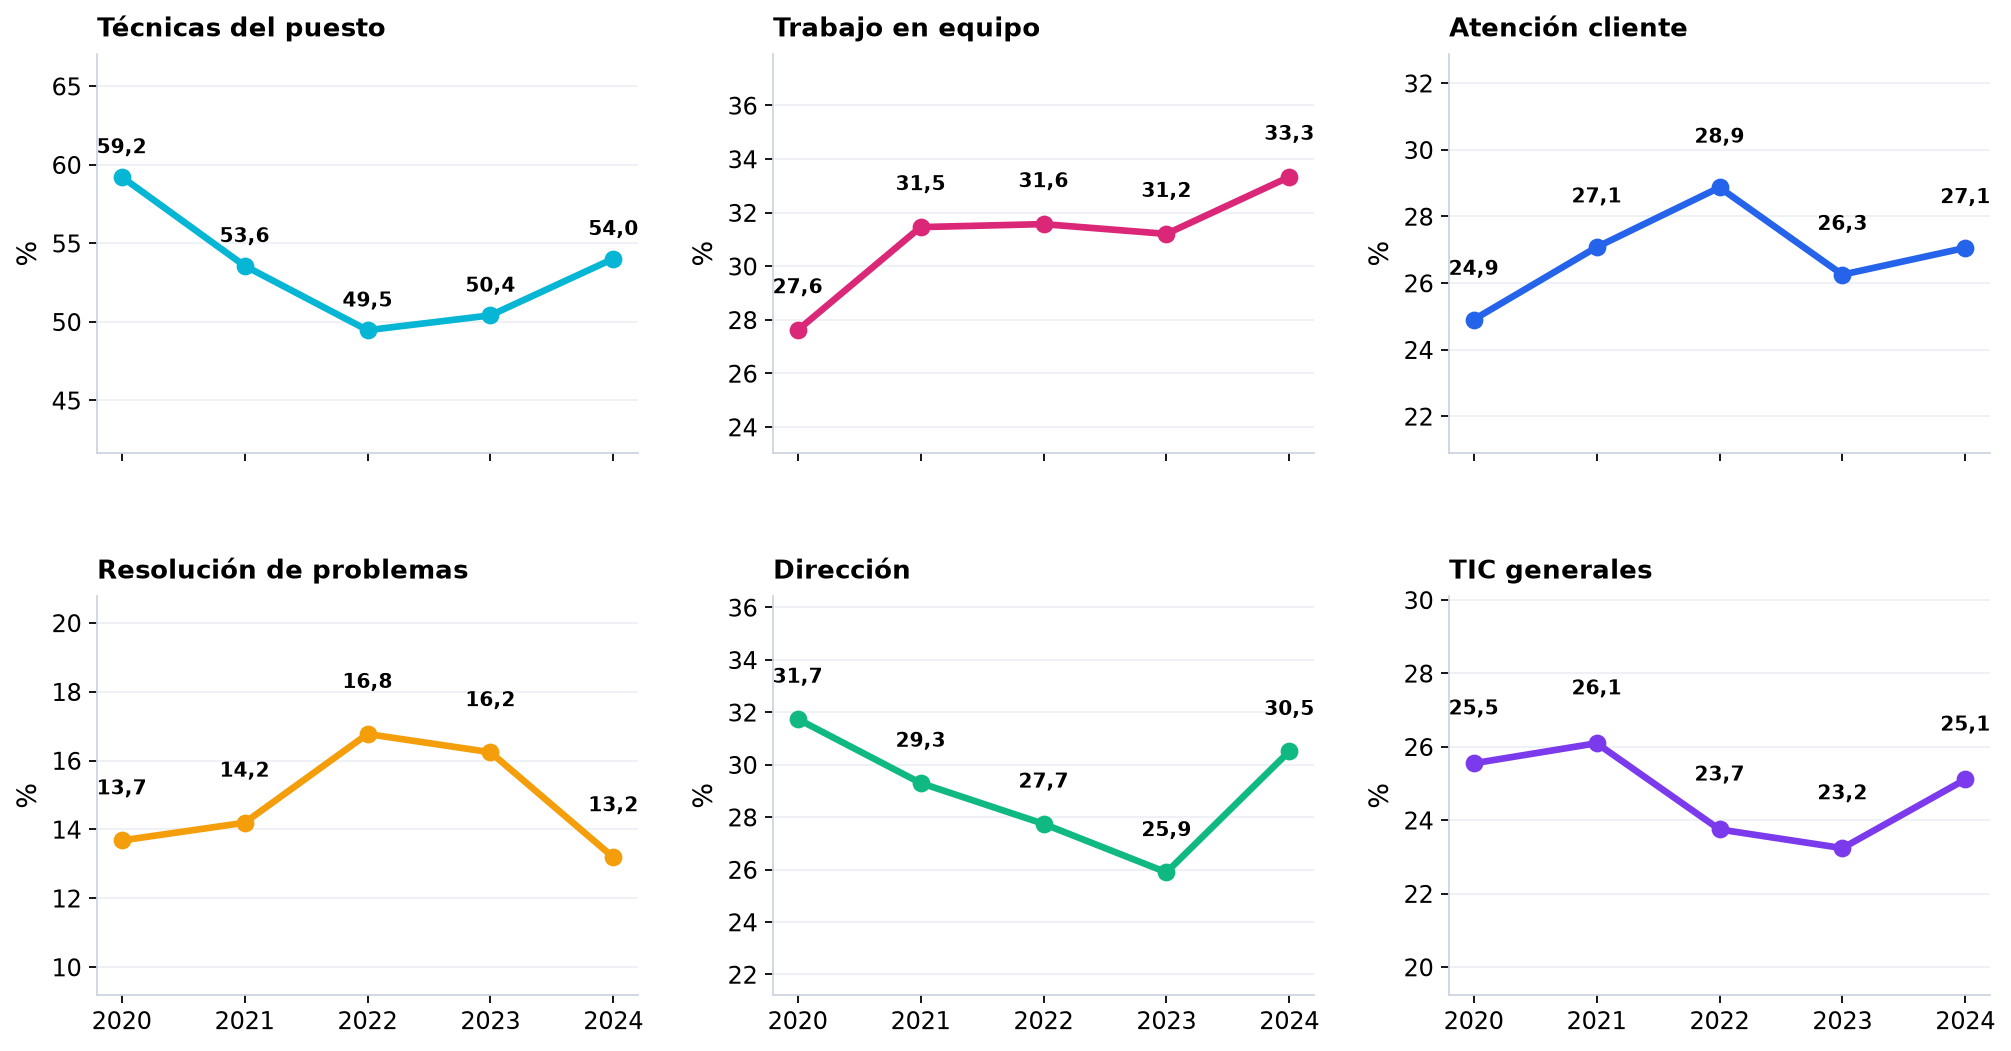

anio,2020,2021,2022,2023,2024,var_2020_2024_pp
competencia_corta,,,,,,
Técnicas del puesto,59.2,53.6,49.5,50.4,54.0,-5.2
Trabajo en equipo,27.6,31.5,31.6,31.2,33.3,5.7
Atención cliente,24.9,27.1,28.9,26.3,27.1,2.2
Resolución de problemas,13.7,14.2,16.8,16.2,13.2,-0.5
Dirección,31.7,29.3,27.7,25.9,30.5,-1.2
TIC generales,25.5,26.1,23.7,23.2,25.1,-0.4


In [21]:
# ============================================================
# EVOLUCIÓN SEPARADA DE COMPETENCIAS FORMADAS
# MÁS DE 499 TRABAJADORES
# ============================================================

competencias_tendencia = {
    "TECNICAS ESPECIFICAS DEL PUESTO DE TRABAJO": "Técnicas del puesto",
    "DE TRABAJO EN EQUIPO": "Trabajo en equipo",
    "DE ATENCION AL PUBLICO/ TRATO A CLIENTES": "Atención cliente",
    "DE RESOLUCION DE PROBLEMAS (LOCALIZACION DE PROBLEMAS O FALLOS, ANALISIS DE SUS CAUSAS Y BUSQUEDA DE SOLUCIONES)": "Resolución de problemas",
    "DE DIRECCION": "Dirección",
    "GENERALES DE TECNOLOGIAS DE LA INFORMACION": "TIC generales",
}

orden_competencias = [
    "Técnicas del puesto",
    "Trabajo en equipo",
    "Atención cliente",
    "Resolución de problemas",
    "Dirección",
    "TIC generales",
]

colores_competencia = {
    "Técnicas del puesto": PALETA["cyan"],
    "Trabajo en equipo": PALETA["rosa"],
    "Atención cliente": PALETA["azul"],
    "Resolución de problemas": PALETA["ambar"],
    "Dirección": PALETA["verde"],
    "TIC generales": PALETA["morado"],
}

evolucion_mas499 = formacion_competencias[
    formacion_competencias["benchmark"].eq("Más de 499 trabajadores")
    & formacion_competencias["clave_competencia"].isin(competencias_tendencia)
].copy()

evolucion_mas499["competencia_corta"] = evolucion_mas499["clave_competencia"].map(
    competencias_tendencia
)


# ============================================================
# GRÁFICO
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(13, 7),
    dpi=160,
    sharex=True,
    facecolor="none"
)

fig.patch.set_alpha(0)
axes = axes.flatten()

for ax, competencia in zip(axes, orden_competencias):

    datos = (
        evolucion_mas499[
            evolucion_mas499["competencia_corta"].eq(competencia)
        ]
        .sort_values("anio")
    )

    preparar_ax(
        ax,
        xlabel="",
        ylabel="%",
        grid="y",
        mostrar_xlabel=False,
        mostrar_ylabel=True
    )

    color = colores_competencia[competencia]

    ax.plot(
        datos["anio"],
        datos["formacion_pct"],
        marker="o",
        linewidth=3,
        markersize=7,
        color=color,
    )

    # Título pequeño de cada gráfico
    ax.set_title(
        competencia,
        fontsize=11.5,
        fontweight="bold",
        color="black",
        loc="left",
        pad=8
    )

    # Etiquetas de porcentaje
    for _, fila in datos.iterrows():
        ax.text(
            fila["anio"],
            fila["formacion_pct"] + 1.2,
            formato_pct(fila["formacion_pct"]),
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="black",
            clip_on=False
        )

    # Escala propia para cada competencia
    margen = max(
        4,
        (datos["formacion_pct"].max() - datos["formacion_pct"].min()) * 0.8
    )

    ax.set_ylim(
        max(0, datos["formacion_pct"].min() - margen),
        datos["formacion_pct"].max() + margen
    )

    ax.set_xticks(ANIOS)
    ax.set_xlabel("")


# Por si quedara algún eje vacío
for ax in axes[len(orden_competencias):]:
    ax.axis("off")


plt.subplots_adjust(
    top=0.94,
    bottom=0.10,
    left=0.07,
    right=0.98,
    hspace=0.36,
    wspace=0.25
)

plt.show()


# ============================================================
# TABLA DE VARIACIÓN
# ============================================================

variacion_mas499 = evolucion_mas499.pivot(
    index="competencia_corta",
    columns="anio",
    values="formacion_pct",
)

variacion_mas499["var_2020_2024_pp"] = (
    variacion_mas499[2024] - variacion_mas499[2020]
)

display(
    variacion_mas499
    .loc[orden_competencias]
    .round(1)
)

### Evolución 2021-2024 de competencias prioritarias

- **Tabla:** EAL-16, Total empresas.
- **Indicador:** porcentaje que responde `Bastante + Mucho`.
- **Lectura:** muestra si las competencias ganan o pierden posición en la agenda empresarial.
- **Cautela:** tendencia descriptiva; no se incluye 2020 porque cambian estructura y categorías.

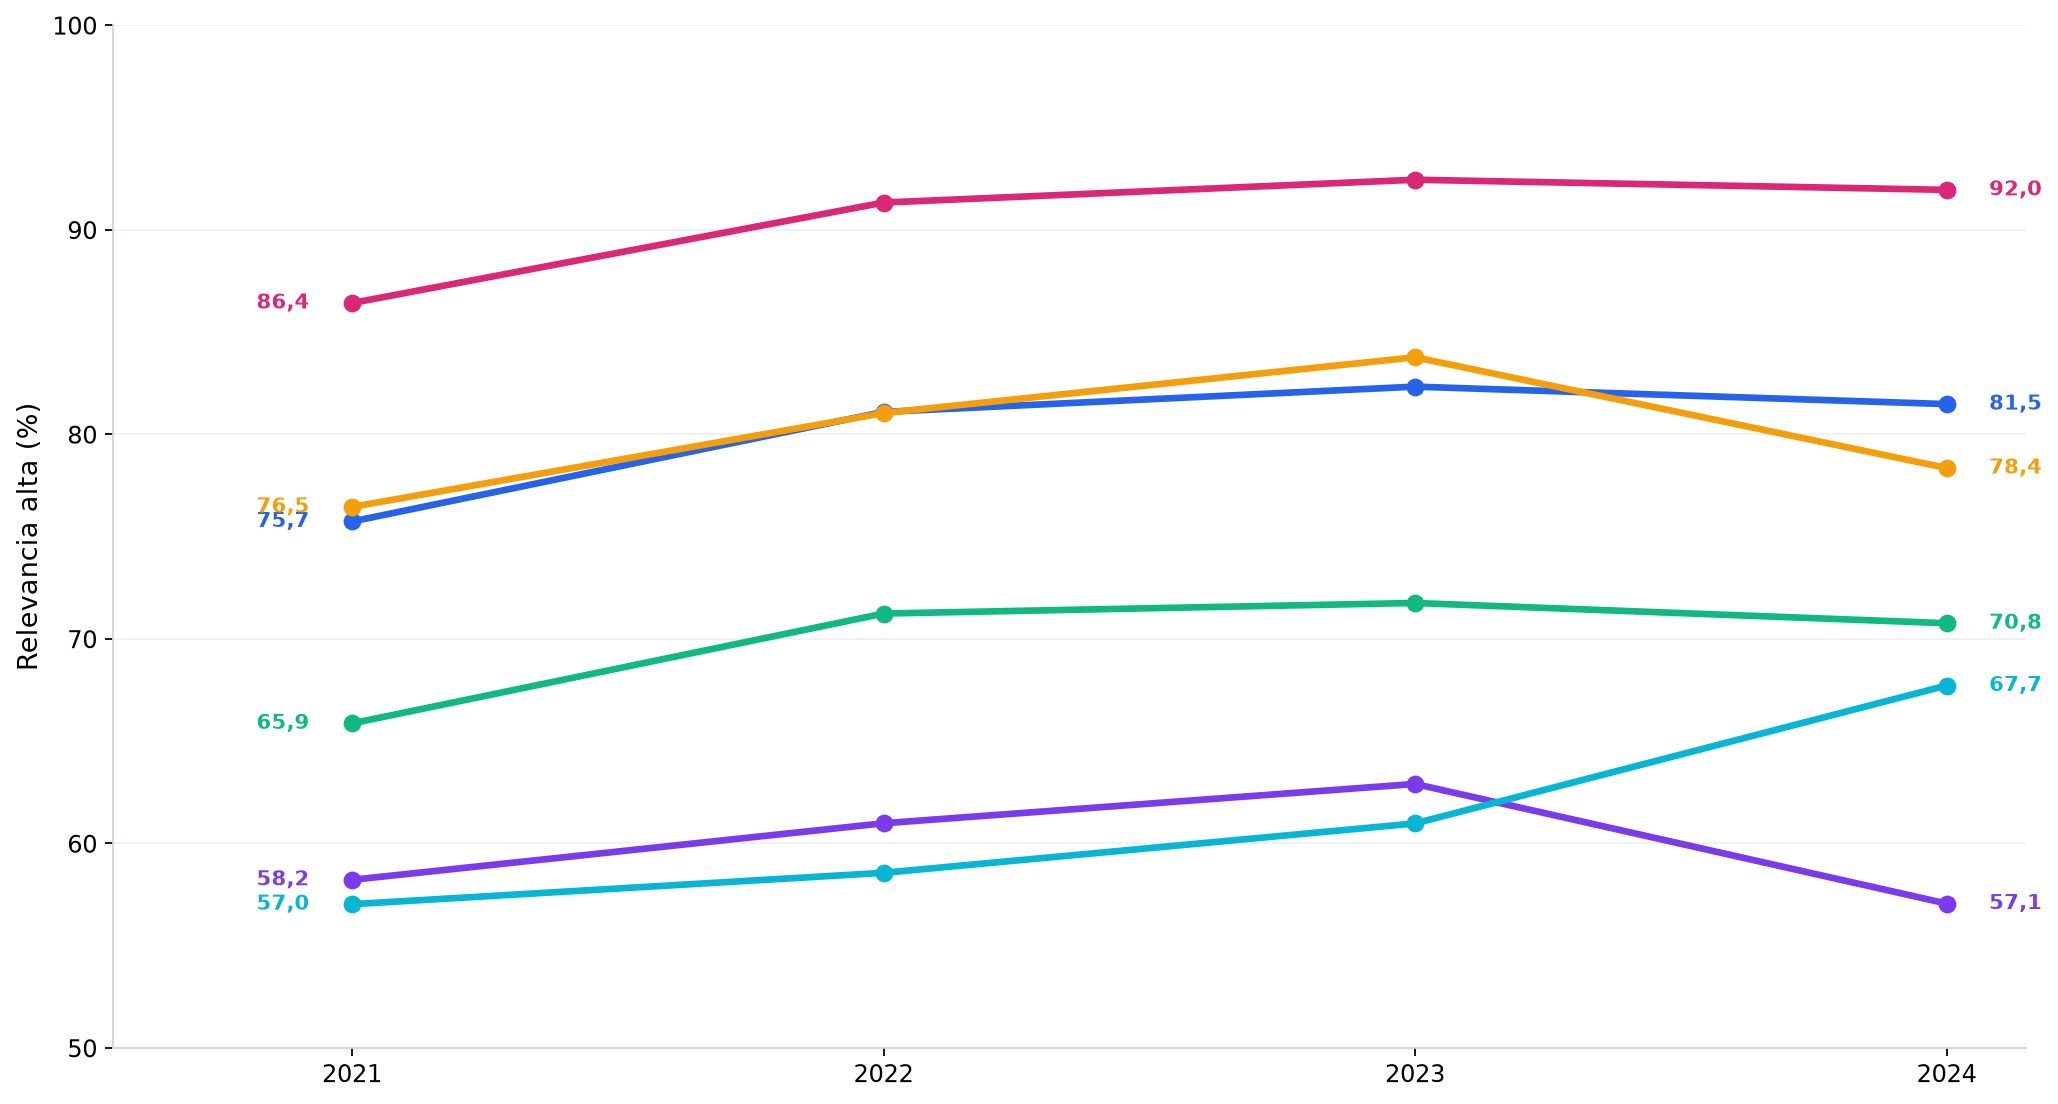

anio,2021,2022,2023,2024,var_2021_2024_pp
competencia_corta,,,,,
Trabajo en equipo,86.4,91.3,92.4,92.0,5.5
Atención cliente,75.7,81.1,82.3,81.5,5.7
Resolución de problemas,76.5,81.0,83.8,78.4,1.9
Dirección,65.9,71.2,71.8,70.8,4.9
Técnicas del puesto,57.0,58.6,61.0,67.7,10.7
TIC generales,58.2,61.0,62.9,57.1,-1.2


In [22]:
# ============================================================
# EVOLUCIÓN DE LA PRIORIDAD DECLARADA
# ============================================================

competencias_prioridad_tendencia = {
    "TECNICAS ESPECIFICAS DEL PUESTO DE TRABAJO": "Técnicas del puesto",
    "DE TRABAJO EN EQUIPO": "Trabajo en equipo",
    "DE ATENCION AL PUBLICO/ TRATO A CLIENTES": "Atención cliente",
    "DE RESOLUCION DE PROBLEMAS (LOCALIZACION DE PROBLEMAS O FALLOS, ANALISIS DE SUS CAUSAS Y BUSQUEDA DE SOLUCIONES)": "Resolución de problemas",
    "DE DIRECCION": "Dirección",
    "GENERALES DE TECNOLOGIAS DE LA INFORMACION": "TIC generales",
}

evolucion_prioridad = prioridad_competencias[
    prioridad_competencias["benchmark"].eq("Total empresas")
    & prioridad_competencias["anio"].between(2021, 2024)
    & prioridad_competencias["clave_competencia"].isin(competencias_prioridad_tendencia)
].copy()

evolucion_prioridad["competencia_corta"] = evolucion_prioridad["clave_competencia"].map(
    competencias_prioridad_tendencia
)

# Colores usando la paleta base actual
colores_prioridad = {
    "Técnicas del puesto": PALETA["principal"] if "principal" in PALETA else PALETA["cyan"],
    "Trabajo en equipo": PALETA["secundario"] if "secundario" in PALETA else PALETA["rosa"],
    "Atención cliente": PALETA["azul"] if "azul" in PALETA else PALETA["gris"],
    "Resolución de problemas": PALETA["alerta"] if "alerta" in PALETA else PALETA["ambar"],
    "Dirección": PALETA["verde"] if "verde" in PALETA else PALETA["gris"],
    "TIC generales": PALETA["morado"] if "morado" in PALETA else PALETA["neutro"],
}

fig, ax = plt.subplots(figsize=(13, 7), dpi=160)

preparar_ax(
    ax,
    xlabel="",
    ylabel="Relevancia alta (%)",
    grid="y",
    mostrar_xlabel=False,
    mostrar_ylabel=True
)

for competencia, datos in evolucion_prioridad.groupby("competencia_corta"):
    datos = datos.sort_values("anio")
    color = colores_prioridad[competencia]

    ax.plot(
        datos["anio"],
        datos["prioridad_pct"],
        marker="o",
        linewidth=3,
        markersize=7,
        color=color
    )

    primero = datos.iloc[0]
    ultimo = datos.iloc[-1]

    # Valor inicial: 2021
    ax.text(
        primero["anio"] - 0.08,
        primero["prioridad_pct"],
        formato_pct(primero["prioridad_pct"]),
        color=color,
        fontsize=9.5,
        fontweight="bold",
        va="center",
        ha="right",
        clip_on=False
    )

    # Valor final: 2024
    ax.text(
        ultimo["anio"] + 0.08,
        ultimo["prioridad_pct"],
        formato_pct(ultimo["prioridad_pct"]),
        color=color,
        fontsize=9.5,
        fontweight="bold",
        va="center",
        ha="left",
        clip_on=False
    )
    

ax.set_xlim(2020.55, 2024.15)
ax.set_ylim(50, 100)
ax.set_xticks([2021, 2022, 2023, 2024])

plt.tight_layout()
plt.show()


# ============================================================
# TABLA DE VARIACIÓN
# ============================================================

variacion_prioridad = evolucion_prioridad.pivot(
    index="competencia_corta",
    columns="anio",
    values="prioridad_pct"
)

variacion_prioridad["var_2021_2024_pp"] = (
    variacion_prioridad[2024] - variacion_prioridad[2021]
)

display(
    variacion_prioridad.sort_values(2024, ascending=False).round(1)
)

Formación efectivo 2020_2024

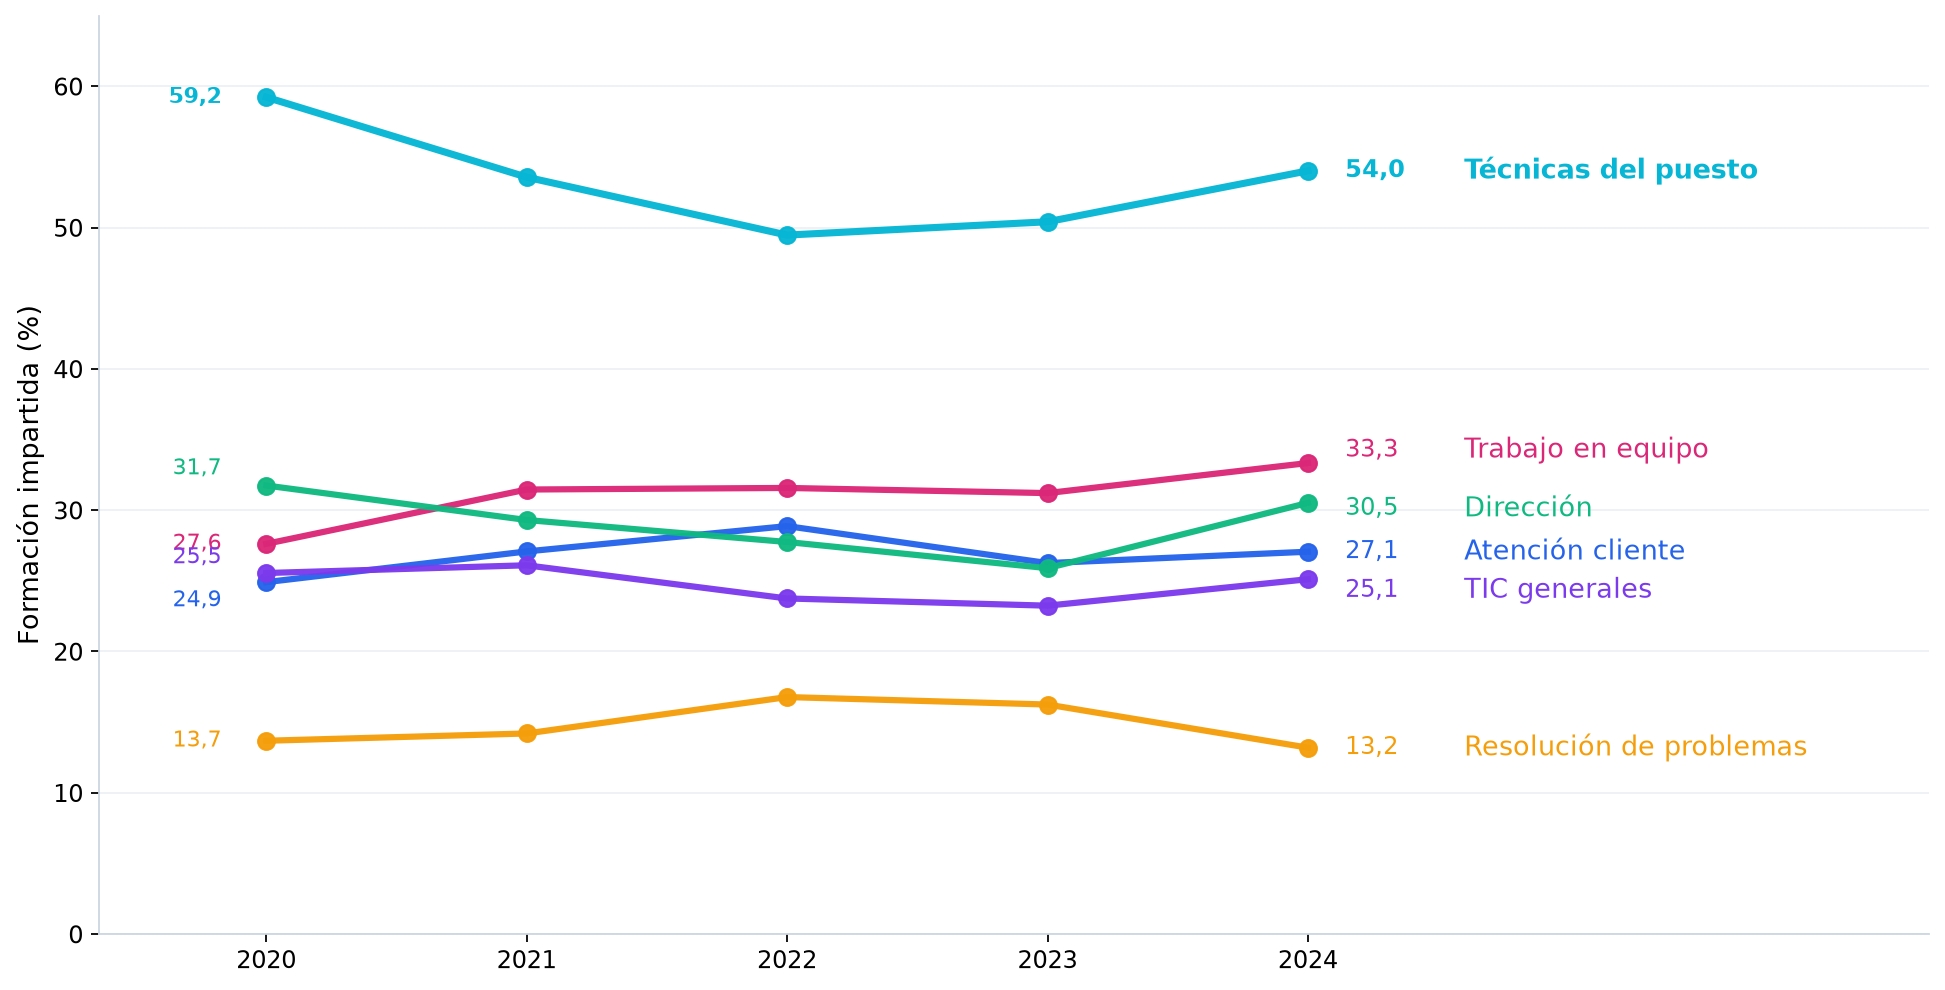

anio,2020,2021,2022,2023,2024,var_2020_2024_pp
competencia_corta,,,,,,
Técnicas del puesto,59.2,53.6,49.5,50.4,54.0,-5.2
Trabajo en equipo,27.6,31.5,31.6,31.2,33.3,5.7
Atención cliente,24.9,27.1,28.9,26.3,27.1,2.2
Resolución de problemas,13.7,14.2,16.8,16.2,13.2,-0.5
Dirección,31.7,29.3,27.7,25.9,30.5,-1.2
TIC generales,25.5,26.1,23.7,23.2,25.1,-0.4


In [23]:
# ============================================================
# FORMACIÓN EFECTIVA · GRANDES EMPRESAS
# ============================================================

competencias_formacion_ampliada = {
    "TECNICAS ESPECIFICAS DEL PUESTO DE TRABAJO": "Técnicas del puesto",
    "DE TRABAJO EN EQUIPO": "Trabajo en equipo",
    "DE ATENCION AL PUBLICO/ TRATO A CLIENTES": "Atención cliente",
    "DE RESOLUCION DE PROBLEMAS (LOCALIZACION DE PROBLEMAS O FALLOS, ANALISIS DE SUS CAUSAS Y BUSQUEDA DE SOLUCIONES)": "Resolución de problemas",
    "DE DIRECCION": "Dirección",
    "GENERALES DE TECNOLOGIAS DE LA INFORMACION": "TIC generales",
}

orden_formacion_ampliada = [
    "Técnicas del puesto",
    "Trabajo en equipo",
    "Atención cliente",
    "Resolución de problemas",
    "Dirección",
    "TIC generales",
]

colores_formacion_ampliada = {
    "Técnicas del puesto": PALETA["cyan"],
    "Trabajo en equipo": PALETA["rosa"],
    "Atención cliente": PALETA["azul"],
    "Resolución de problemas": PALETA["ambar"],
    "Dirección": PALETA["verde"],
    "TIC generales": PALETA["morado"],
}

formacion_ampliada = formacion_competencias[
    formacion_competencias["benchmark"].eq("Más de 499 trabajadores")
    & formacion_competencias["clave_competencia"].isin(competencias_formacion_ampliada)
].copy()

formacion_ampliada["competencia_corta"] = formacion_ampliada["clave_competencia"].map(
    competencias_formacion_ampliada
)

formacion_ampliada_pivot = (
    formacion_ampliada
    .pivot_table(
        index="anio",
        columns="competencia_corta",
        values="formacion_pct",
        aggfunc="first",
    )
    .reindex(ANIOS)
)


# ============================================================
# GRÁFICO
# ============================================================

fig, ax = plt.subplots(figsize=(13, 7), dpi=160, facecolor="none")

preparar_ax(
    ax,
    xlabel="",
    ylabel="Formación impartida (%)",
    grid="y",
    mostrar_xlabel=False,
    mostrar_ylabel=True
)


# ------------------------------------------------------------
# EJE X COMPACTADO
# ------------------------------------------------------------

factor_compresion = 0.70

x_posiciones = np.arange(len(ANIOS)) * factor_compresion
mapa_x = dict(zip(ANIOS, x_posiciones))


# ------------------------------------------------------------
# POSICIONES DE ETIQUETAS DERECHA
# ------------------------------------------------------------

x_2024 = mapa_x[2024]
x_pct_2024 = x_2024 + 0.10
x_categoria_2024 = x_2024 + 0.42


# ------------------------------------------------------------
# AJUSTES MANUALES PARA EVITAR CHOQUES ENTRE ETIQUETAS
# ------------------------------------------------------------

offset_2020 = {
    "Técnicas del puesto": 0.0,
    "Trabajo en equipo": 0.0,
    "Atención cliente": -1.3,
    "Resolución de problemas": 0.0,
    "Dirección": 1.2,
    "TIC generales": 1.1,
}

offset_2024 = {
    "Técnicas del puesto": 0.0,
    "Trabajo en equipo": 0.9,
    "Atención cliente": 0.0,
    "Resolución de problemas": 0.0,
    "Dirección": -0.4,
    "TIC generales": -0.8,
}


# ------------------------------------------------------------
# LÍNEAS + ETIQUETAS
# ------------------------------------------------------------

for competencia in orden_formacion_ampliada:

    serie = formacion_ampliada_pivot[competencia]
    color = colores_formacion_ampliada[competencia]

    x = [mapa_x[anio] for anio in serie.index]

    ax.plot(
        x,
        serie.values,
        marker="o",
        linewidth=3.2 if competencia == "Técnicas del puesto" else 2.8,
        markersize=7.5,
        color=color,
        alpha=0.96,
    )

    # Porcentaje inicial 2020
    ax.text(
        mapa_x[2020] - 0.12,
        serie.loc[2020] + offset_2020.get(competencia, 0),
        formato_pct(serie.loc[2020]),
        ha="right",
        va="center",
        fontsize=10,
        color=color,
        fontweight="bold" if competencia == "Técnicas del puesto" else "normal",
        clip_on=False
    )

    # Porcentaje final 2024
    ax.text(
        x_pct_2024,
        serie.loc[2024] + offset_2024.get(competencia, 0),
        formato_pct(serie.loc[2024]),
        ha="left",
        va="center",
        fontsize=11,
        color=color,
        fontweight="bold" if competencia == "Técnicas del puesto" else "normal",
        clip_on=False
    )

    # Nombre de la categoría
    ax.text(
        x_categoria_2024,
        serie.loc[2024] + offset_2024.get(competencia, 0),
        competencia,
        ha="left",
        va="center",
        fontsize=12,
        color=color,
        fontweight="bold" if competencia == "Técnicas del puesto" else "normal",
        clip_on=False
    )


# ------------------------------------------------------------
# ESCALAS Y EJES
# ------------------------------------------------------------

ax.set_xlim(mapa_x[2020] - 0.45, x_categoria_2024 + 1.25)
ax.set_ylim(0, 65)

ax.set_xticks(x_posiciones)
ax.set_xticklabels(ANIOS)

ax.set_yticks([0, 10, 20, 30, 40, 50, 60])

# Ya no hace falta cambiar colores aquí:
# preparar_ax() ya deja los labels y ticks en negro.

plt.subplots_adjust(
    top=0.96,
    bottom=0.14,
    left=0.09,
    right=0.97
)

plt.show()


# ============================================================
# TABLA RESUMEN
# ============================================================

formacion_ampliada_resumen = formacion_ampliada_pivot.T.copy()

formacion_ampliada_resumen["var_2020_2024_pp"] = (
    formacion_ampliada_resumen[2024] - formacion_ampliada_resumen[2020]
)

display(
    formacion_ampliada_resumen
    .loc[orden_formacion_ampliada]
    .round(1)
)